In [ ]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('/Urbanomy-data/data/leningrad_oblast/ gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
basline_blocks.loc[142]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                              1568.375787
build_floor_area                                            1568.375787
living_area                                                 1202.729596
non_living_area                                              365.646192
population                                                      

In [ ]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('/Urbanomy-data/data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [7]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [8]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

# Ensure all required features are present in basline_blocks
# If missing morphotype, add it based on existing columns or set a default
if "morphotype" not in basline_blocks.columns:
    basline_blocks["morphotype"] = "UNKNOWN"

# Calculate missing morphological features if needed
required_features = ["fsi", "gsi", "mxi", "l", "area_accessibility"]
for feat in required_features:
    if feat not in basline_blocks.columns:
        basline_blocks[feat] = 0.0

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",0,215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",1,108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2,77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",3,32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",4,30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


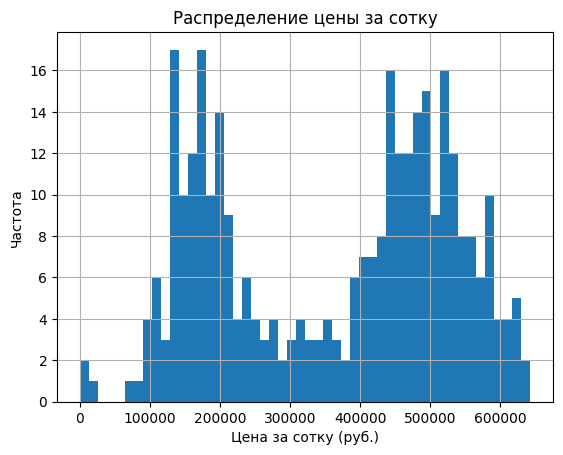

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



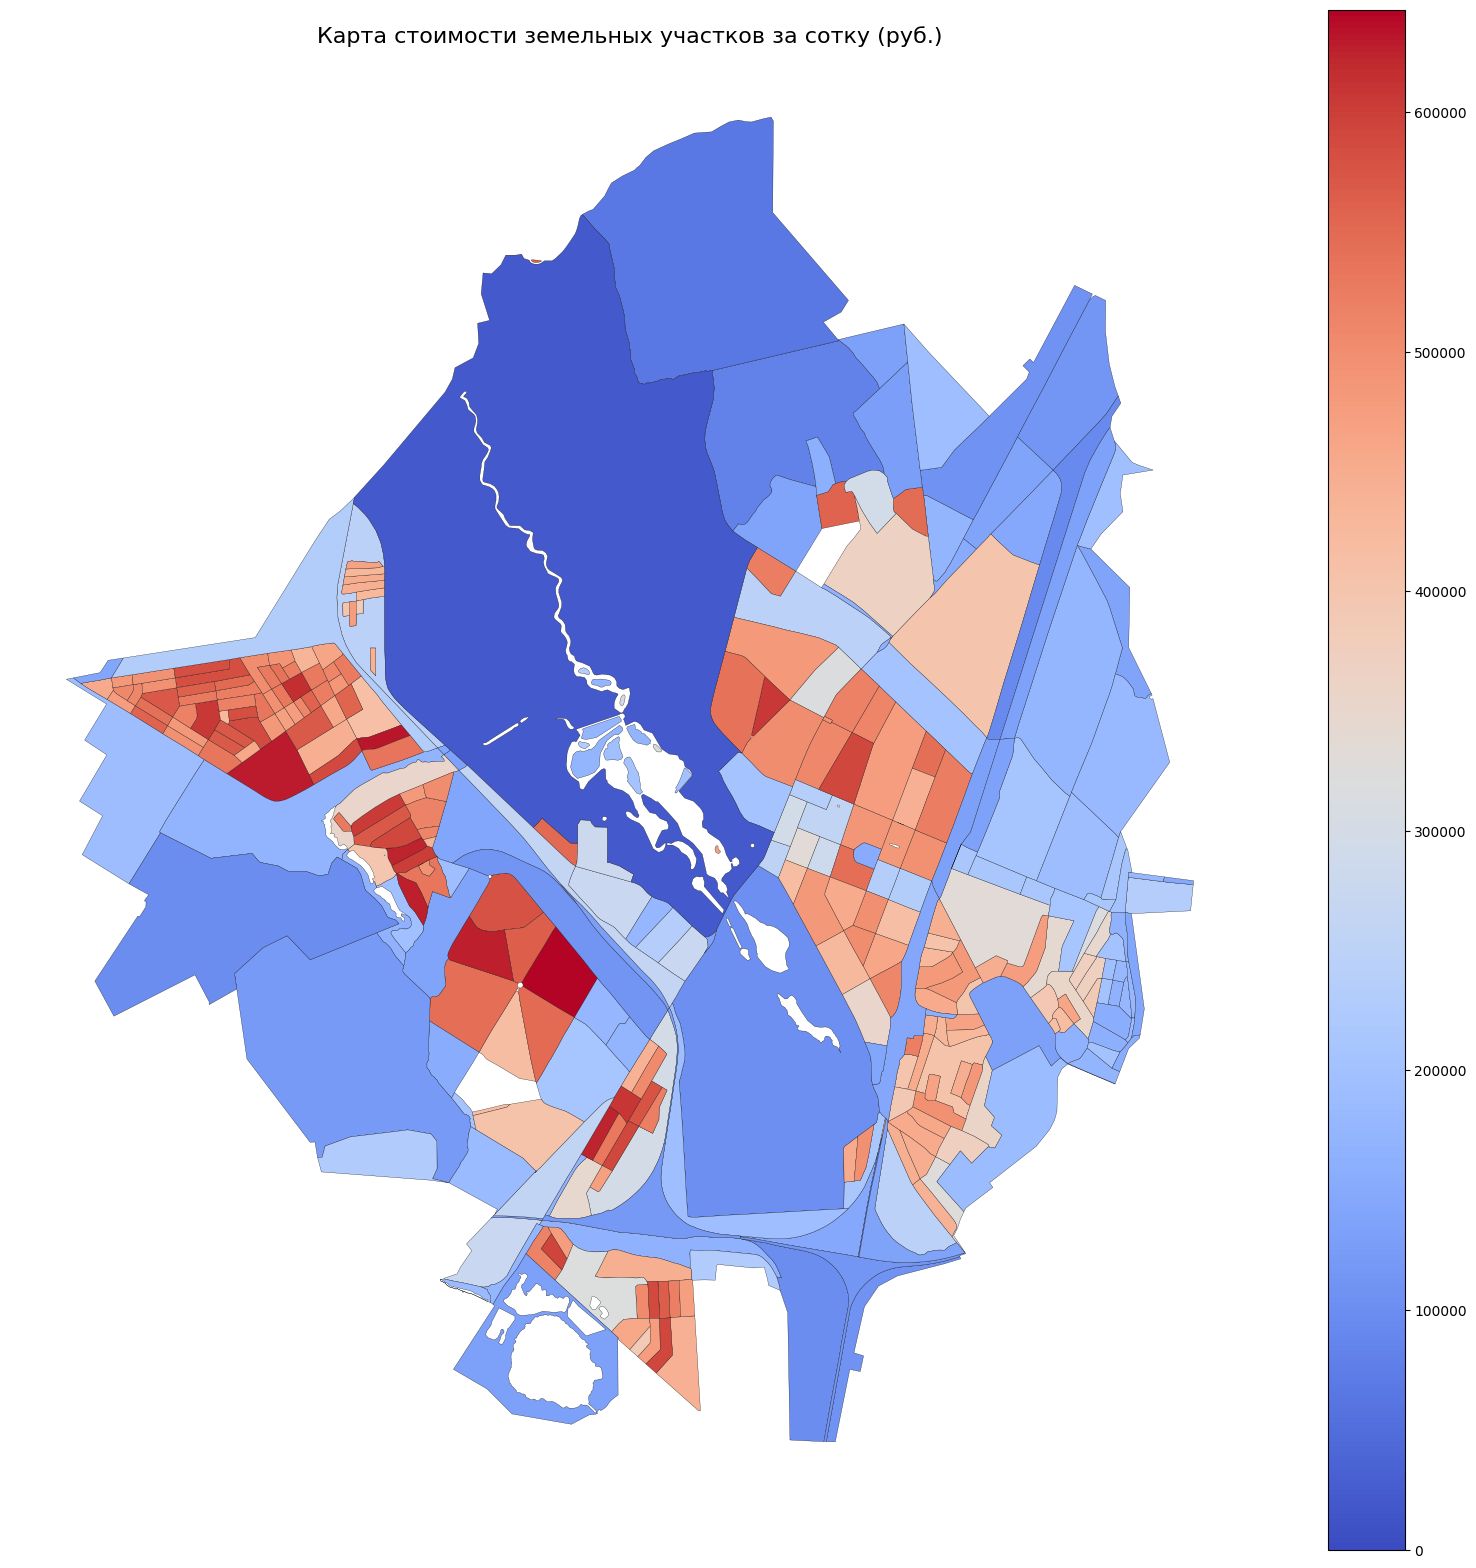

In [10]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

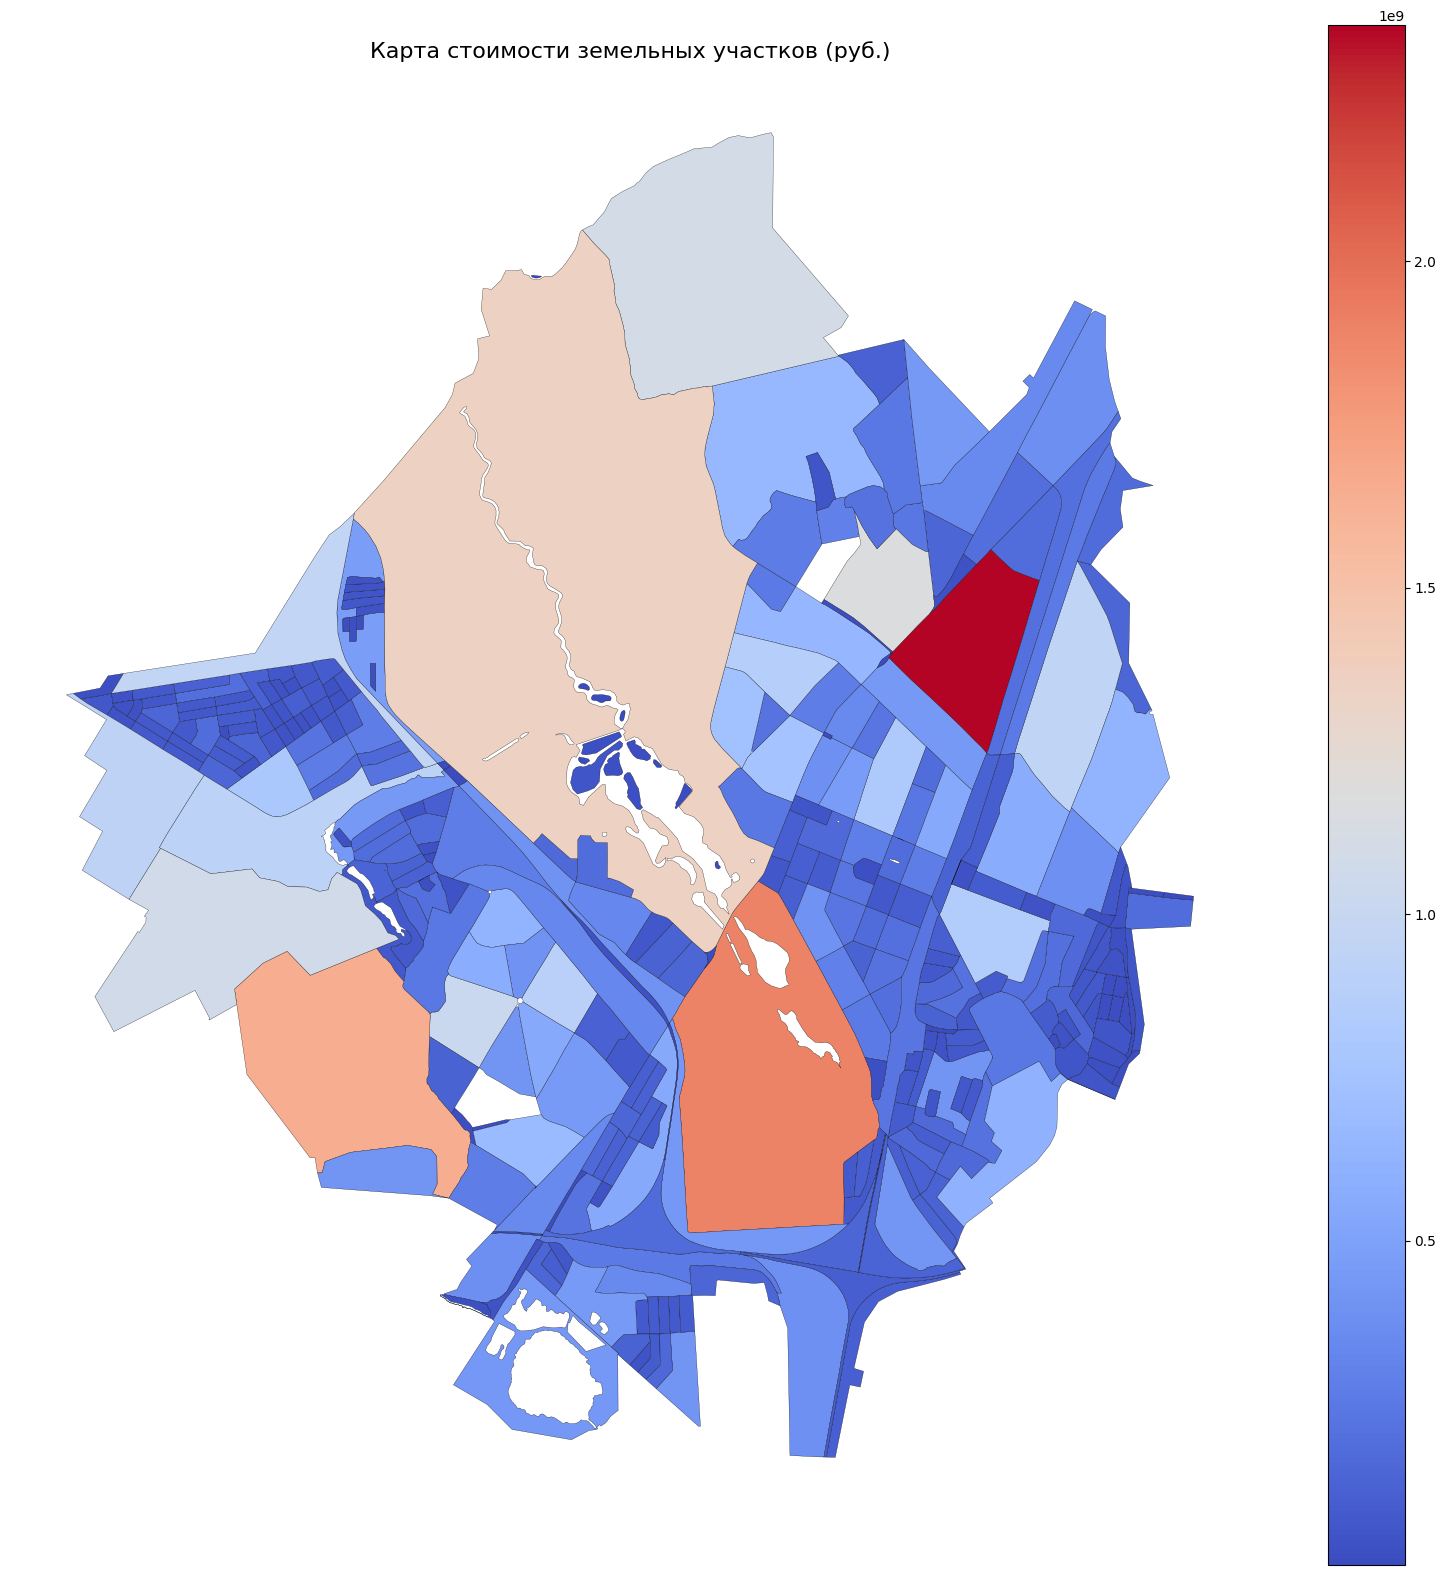

In [11]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [12]:
blocks_clean["id"] = blocks_clean.index

In [13]:
blocks_clean.explore()

BASELINE SCENARIO: Current State Analysis

Total land value (all blocks): 62 951 519 914 ₽

Target block (id=7):
 • Land value: 374 723 309 ₽
 • Land use: LandUse.INDUSTRIAL
 • Build floor area: 3 991 m²
 • Site area: 330 925 m²


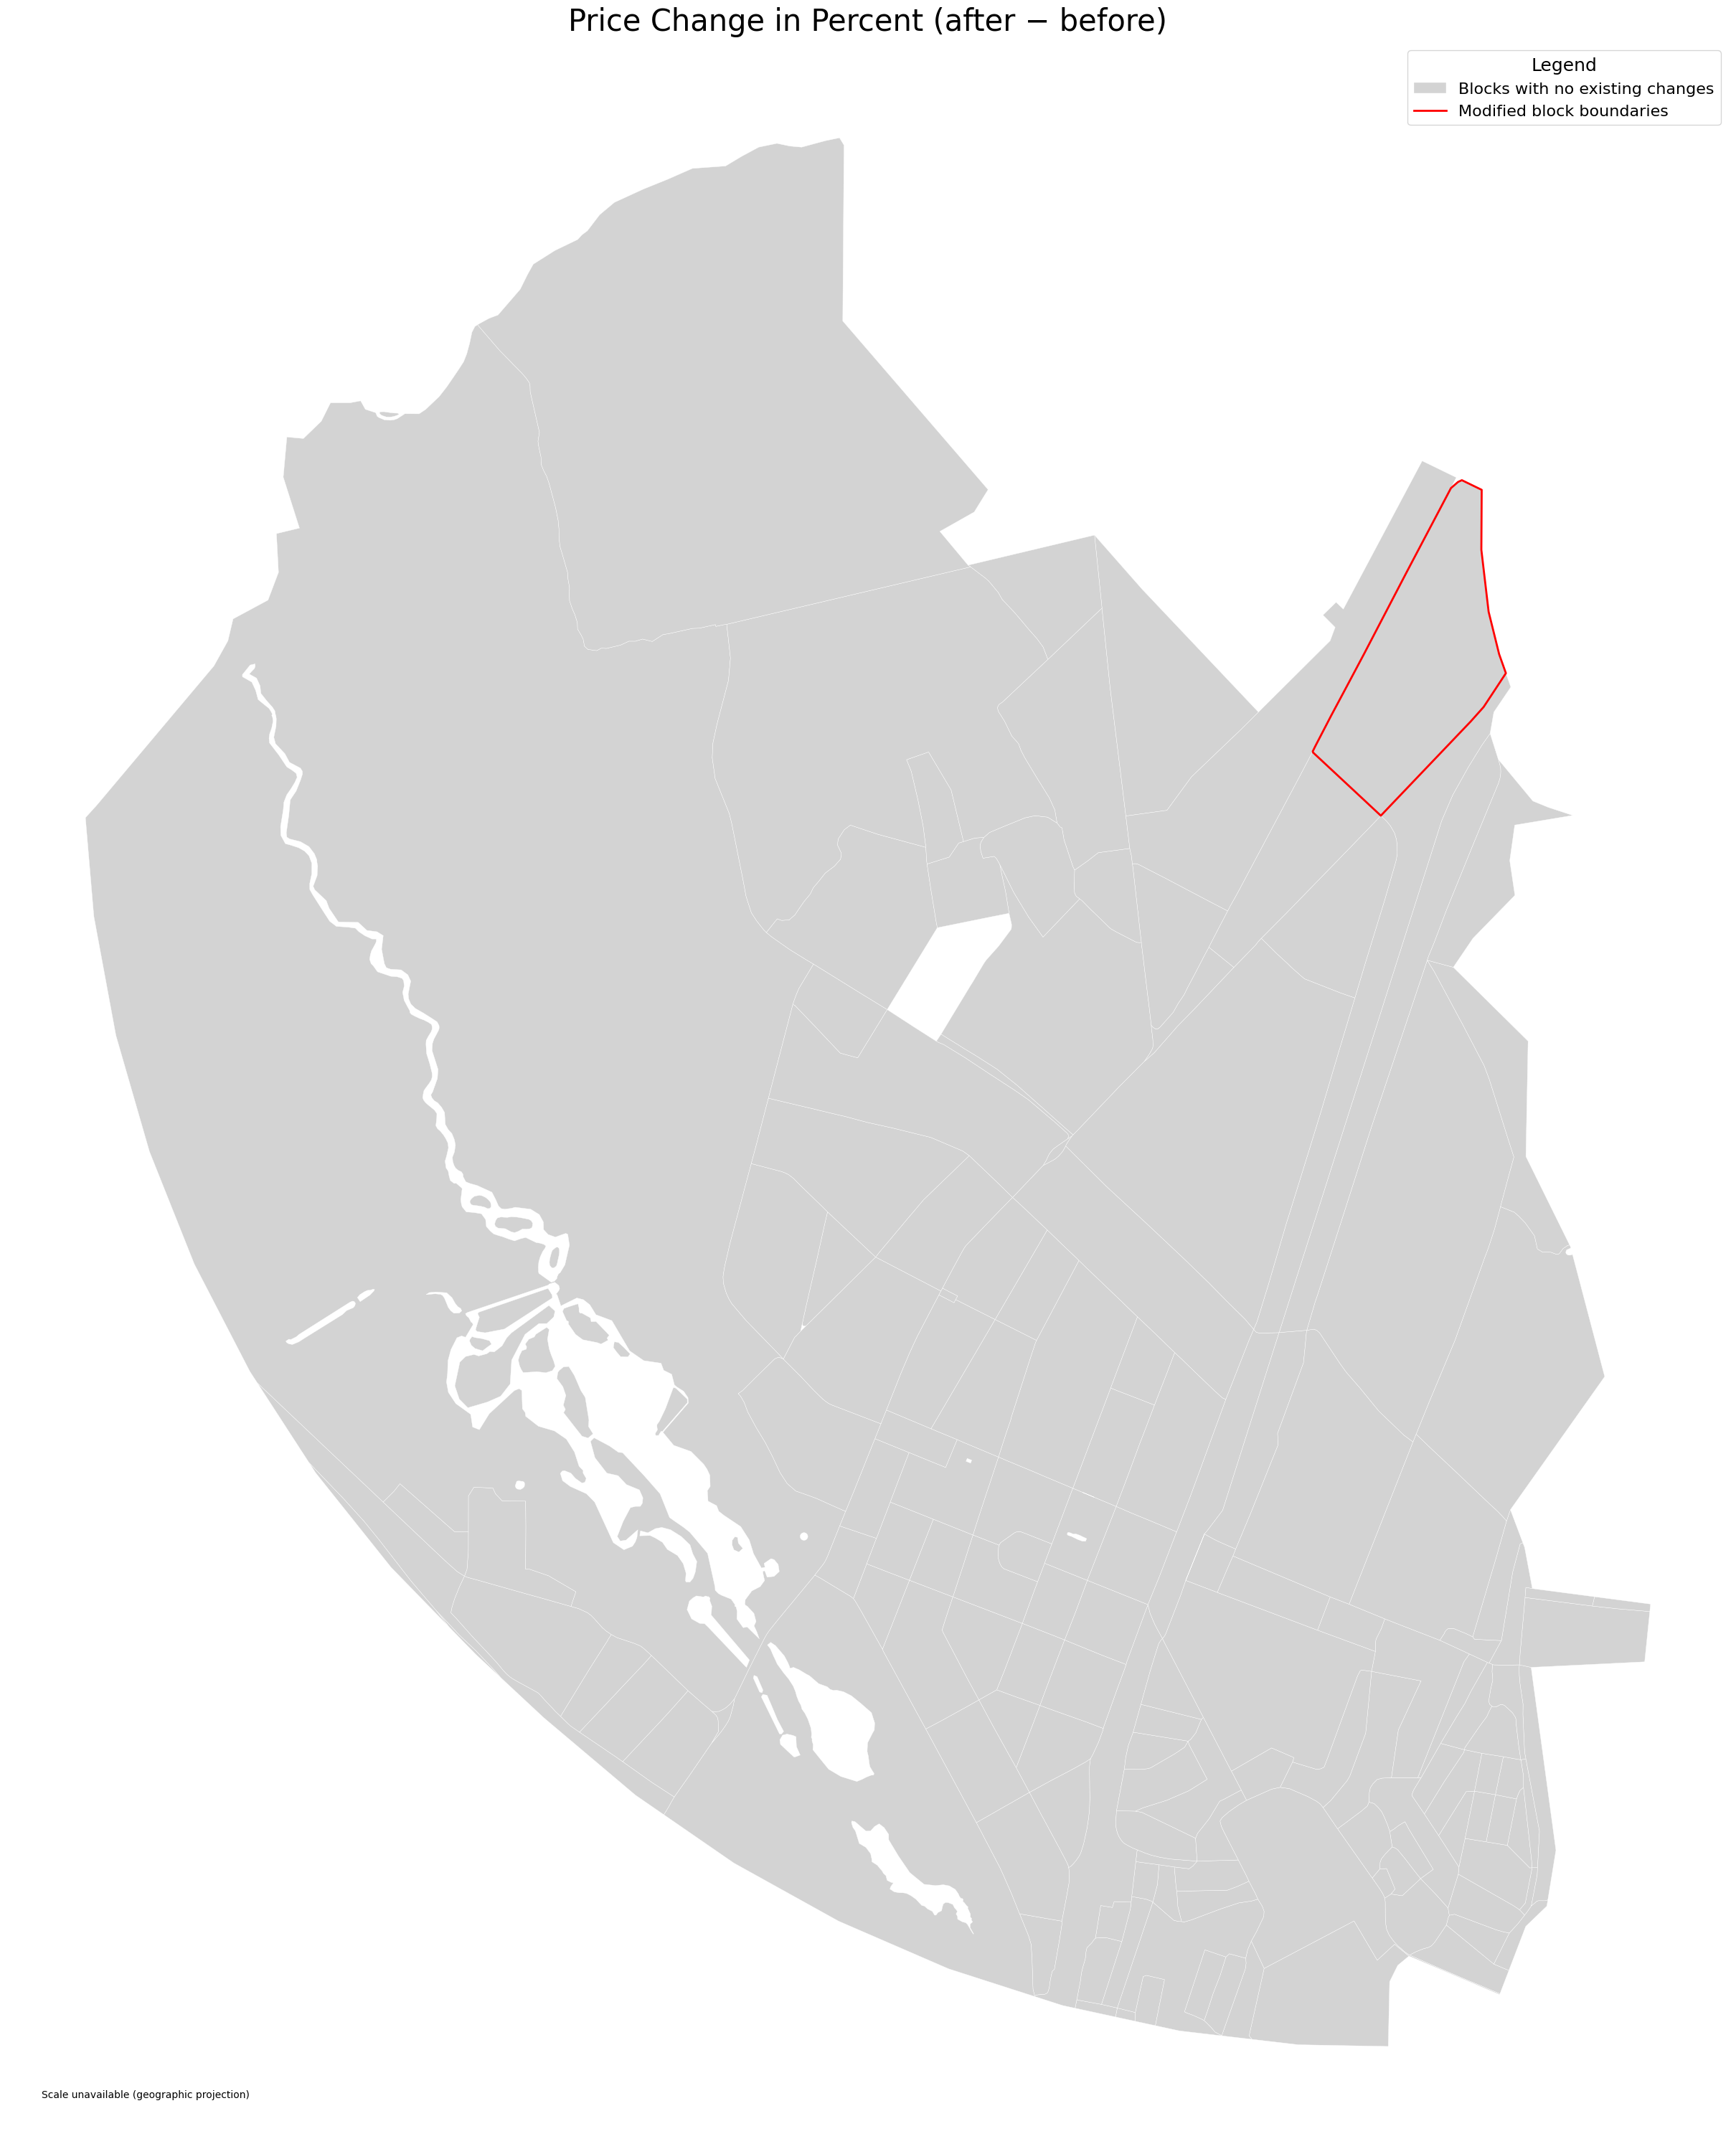


✓ Baseline scenario visualization complete


In [14]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)
import numpy as np
import pandas as pd
target_id = 7
# Add project flag to baseline blocks
blocks_clean["is_project"] = False
blocks_clean.loc[blocks_clean["id"] == target_id, "is_project"] = True

# Prepare baseline blocks for scenario impact visualization
blocks_baseline = blocks_clean.copy()

# Calculate land value with estimator
baseline_estimator = LandPriceEstimator(
    model=model,
    blocks=blocks_baseline,
    orig_features=numeric_feats + cat_features,
    categorical_features=cat_features,
    use_service_features=False,
)
blocks_baseline_pred = baseline_estimator.predict()

# Calculate land value per 100m2
blocks_baseline_pred["land_value_per_100m2"] = np.where(
    pd.to_numeric(blocks_baseline_pred["site_area"], errors="coerce") > 0,
    pd.to_numeric(blocks_baseline_pred["land_value"], errors="coerce")
    / pd.to_numeric(blocks_baseline_pred["site_area"], errors="coerce") * 100,
    np.nan,
)

# For baseline scenario (no changes), before and after are the same
blocks_baseline_pred["land_value_before"] = blocks_baseline_pred["land_value"]
blocks_baseline_pred["land_value_after"] = blocks_baseline_pred["land_value"]
blocks_baseline_pred["d_rub"] = 0.0
blocks_baseline_pred["land_value_delta_pct"] = 0.0

# Calculate total baseline value
baseline_total = float(blocks_baseline_pred["land_value"].sum())

print("=" * 60)
print("BASELINE SCENARIO: Current State Analysis")
print("=" * 60)
print(f"\nTotal land value (all blocks): {baseline_total:,.0f} ₽".replace(",", " "))

target_block_baseline = blocks_baseline_pred.loc[blocks_baseline_pred["id"] == target_id].iloc[0]
print(f"\nTarget block (id={target_id}):")
print(f" • Land value: {target_block_baseline['land_value']:,.0f} ₽".replace(",", " "))
print(f" • Land use: {target_block_baseline.get('land_use', 'N/A')}")
print(f" • Build floor area: {target_block_baseline.get('build_floor_area', 0):,.0f} m²".replace(",", " "))
print(f" • Site area: {target_block_baseline.get('site_area', 0):,.0f} m²".replace(",", " "))

# Visualize baseline scenario impact (essentially no change, but for reference)
scenario_result_baseline = plot_scenario_impact(
    blocks=blocks_baseline_pred,
    target_idx=target_id,
    target_id_column="id",
    before_column="land_value_before",
    after_column="land_value_after",
    pct_column="land_value_delta_pct",
    delta_column="d_rub",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)

print("\n✓ Baseline scenario visualization complete")


In [15]:
# Apply a manual scenario to the target block and visualize the impact
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)

# Example manual changes for the target block (adjust as needed)
manual_changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168,
}

# Apply changes
modifier = ScenarioTEPModifier(blocks_clean)
blocks_after_manual = modifier.apply(target_id, manual_changes)
blocks_after_manual['is_project'] = False
blocks_after_manual.loc[blocks_after_manual['id'] == target_id, 'is_project'] = True

# Predict before and after using the same estimator configuration
est_args = dict(orig_features=numeric_feats + cat_features, categorical_features=cat_features, model=model)

est_before = LandPriceEstimator(blocks=blocks_clean, **est_args)
pred_before = est_before.predict()[['id', 'land_value']].rename(columns={'land_value': 'land_value_before'})

est_after = LandPriceEstimator(blocks=blocks_after_manual, **est_args)
pred_after = est_after.predict()[['id', 'land_value']].rename(columns={'land_value': 'land_value_after'})

# Merge predictions and compute deltas
blocks_manual_full = pred_after.merge(pred_before, on='id', how='left', validate='one_to_one')
blocks_manual_full = blocks_manual_full.merge(blocks_after_manual.drop(columns=[c for c in blocks_after_manual.columns if c not in ['id','geometry','is_project','land_use','build_floor_area','site_area']]), on='id', how='left')

blocks_manual_full['d_rub'] = blocks_manual_full['land_value_after'] - blocks_manual_full['land_value_before']
blocks_manual_full['land_value_delta_pct'] = ((blocks_manual_full['land_value_after'] / blocks_manual_full['land_value_before'] - 1.0) * 100).replace([np.inf, -np.inf], np.nan)

# Print summary for the modified block
row = blocks_manual_full.loc[blocks_manual_full['id'] == target_id].iloc[0]
print(f"Modified block (id={target_id}): before={row['land_value_before']:,.0f} ₽, after={row['land_value_after']:,.0f} ₽, Δ={row['d_rub']:+,.0f} ₽")

# Visualize
scenario_result_manual = plot_scenario_impact(
    blocks=blocks_manual_full,
    target_idx=target_id,
    target_id_column='id',
    before_column='land_value_before',
    after_column='land_value_after',
    pct_column='land_value_delta_pct',
    delta_column='d_rub',
    figsize=(25, 35),
)

print('\n✓ Manual scenario applied and visualized')

Modified block (id=7): before=374,723,309 ₽, after=667,470,412 ₽, Δ=+292,747,103 ₽


AttributeError: 'DataFrame' object has no attribute 'crs'

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_55303/2926021733.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


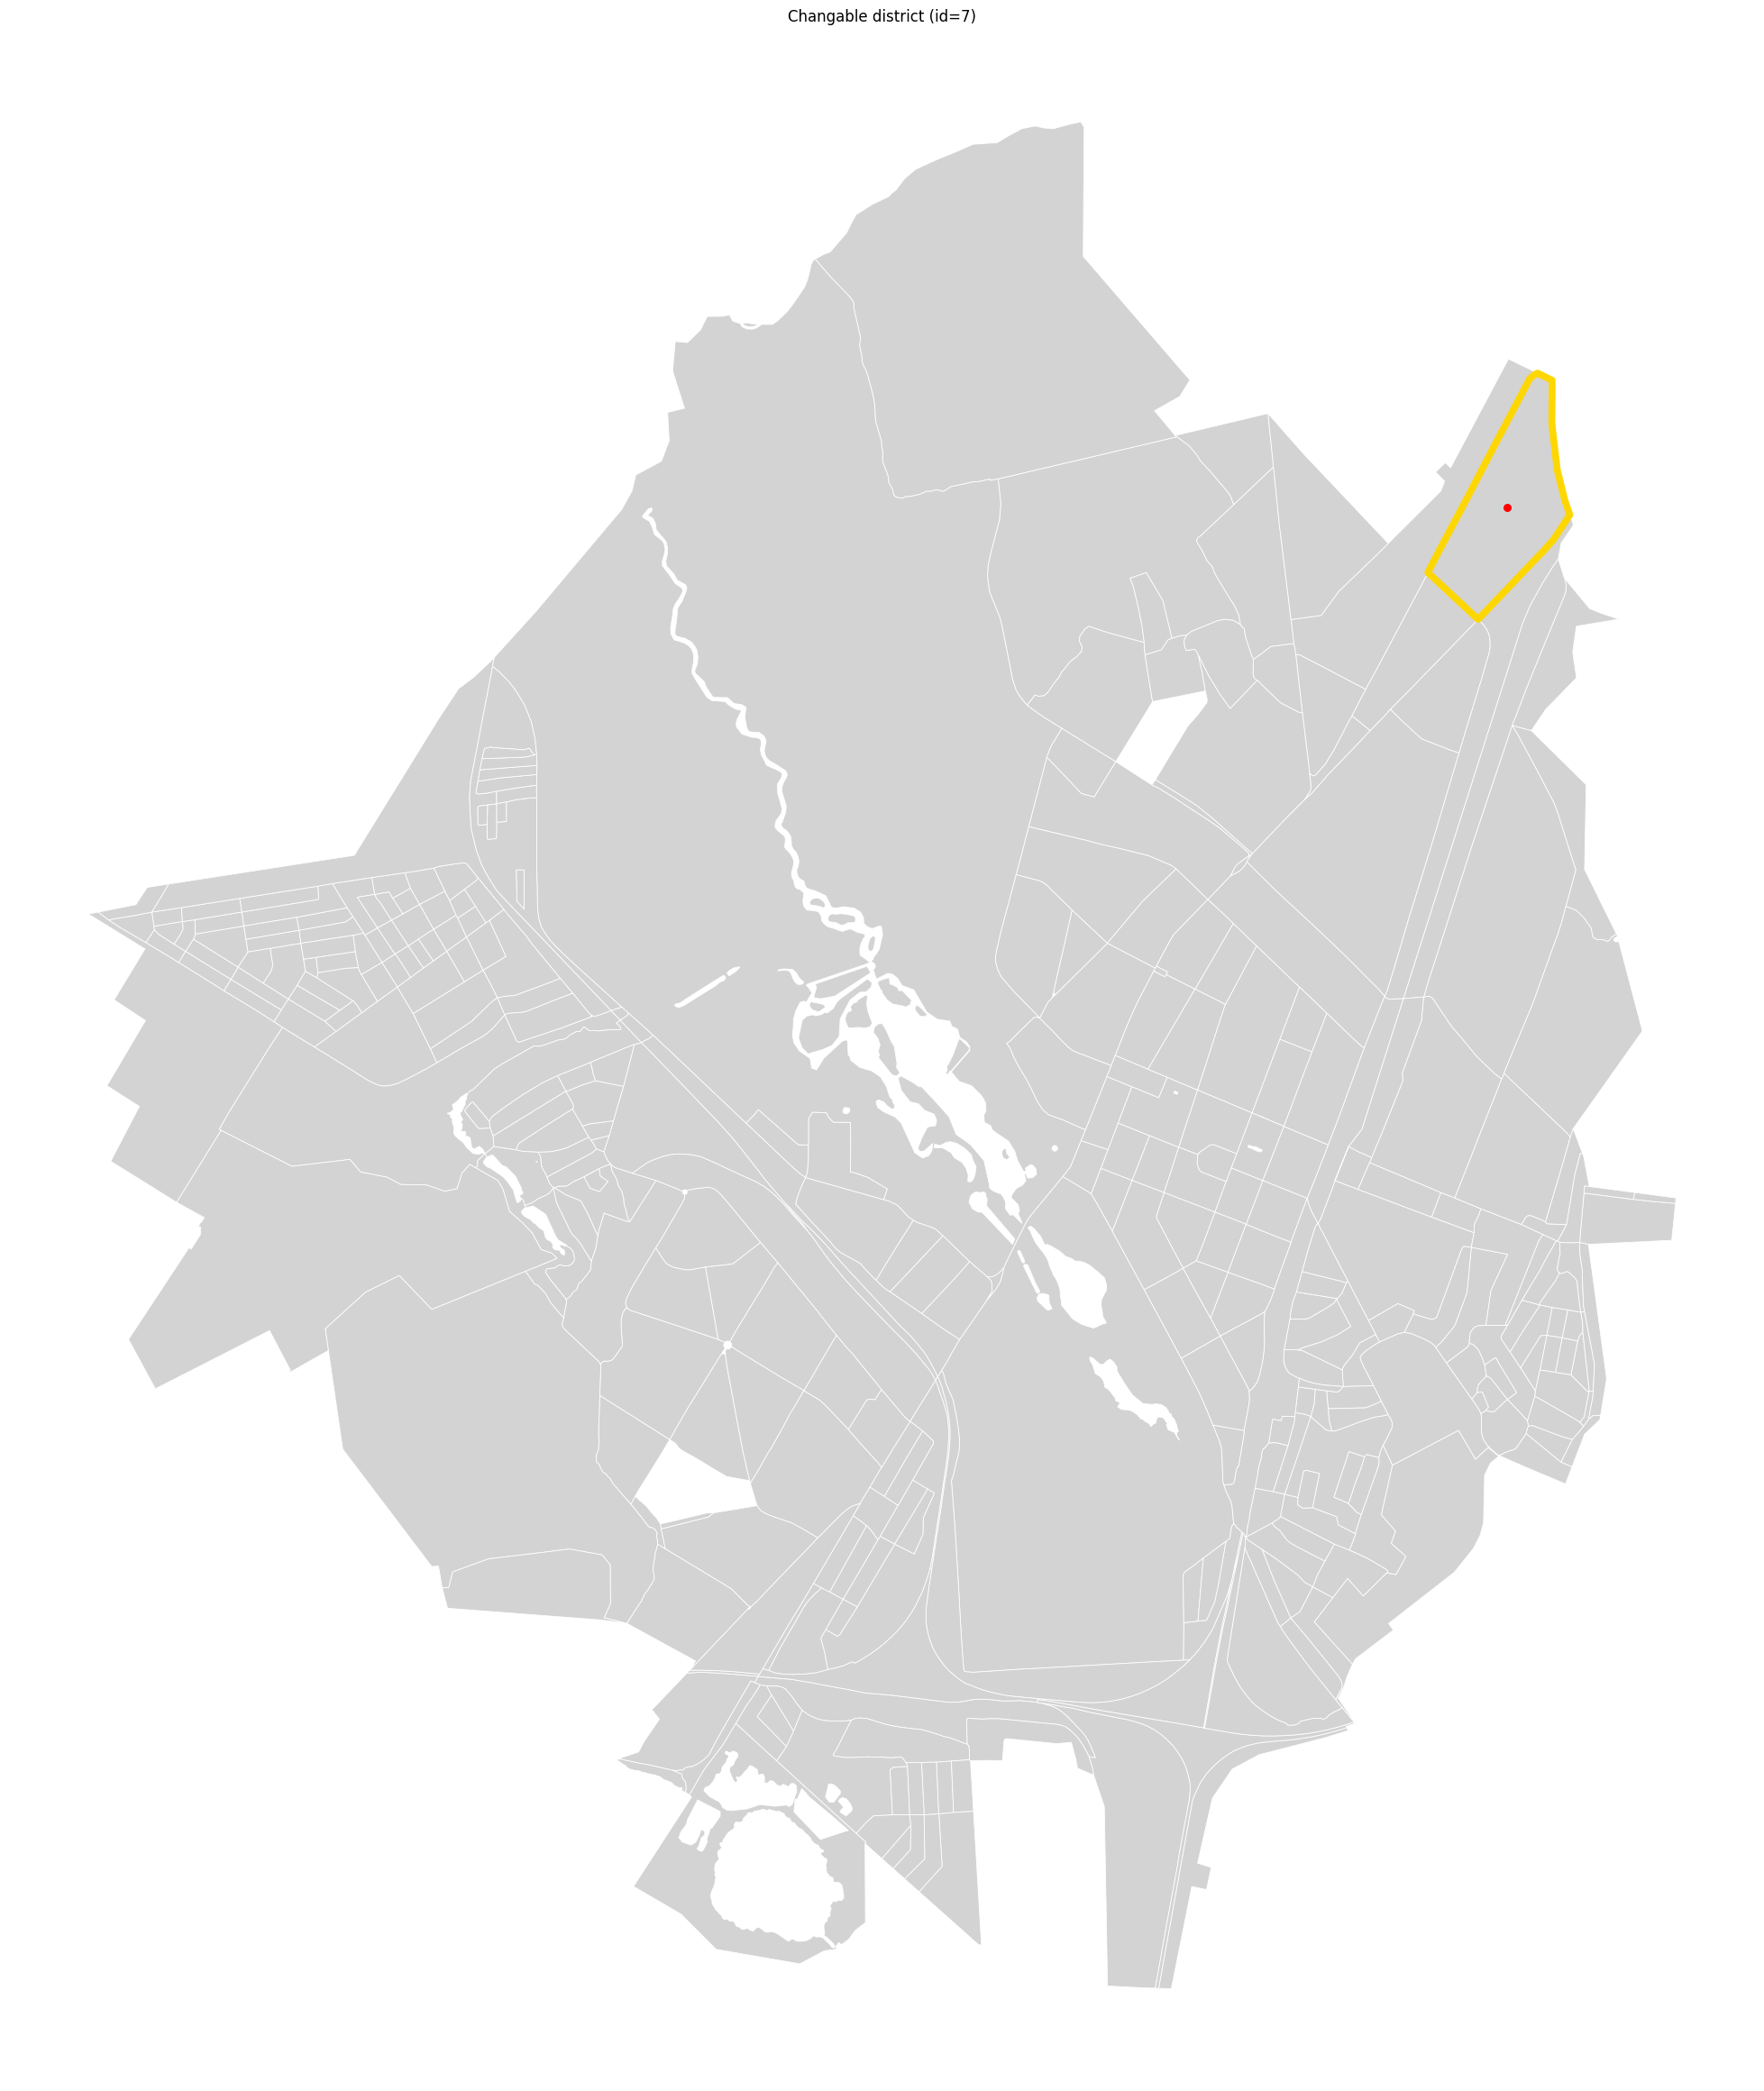

In [ ]:
import matplotlib.pyplot as plt

target_id = 7
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Changable district (id={target_id})")
ax.axis("off")
plt.show()


In [ ]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

## Оптимизация района

In [16]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem

site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

problem = DistrictProblem(
    blocks=blocks_clean,
    target_id=target_id,
    model=model,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    # "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)


## MOEAD

In [18]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import (
    optimize_moead_with_llm,
    StrategicAlignmentScorer,
    optimize_moead_without_llm
    )
from urbanomy.methods.land_value_modeling import build_pareto_front_dataframe


In [19]:

res_mpoead_no_llm, problem_moaed = optimize_moead_without_llm(problem, generations=20, population_size=10)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       11 |      4 |             - |             -
     2 |       22 |      6 |  0.2676821247 |         ideal
     2 |       22 |      6 |  0.2676821247 |         ideal
     3 |       33 |      8 |  0.1064961601 |         ideal
     3 |       33 |      8 |  0.1064961601 |         ideal
     4 |       44 |      9 |  0.4386142437 |         ideal
     4 |       44 |      9 |  0.4386142437 |         ideal
     5 |       55 |     11 |  2.038767E+09 |         ideal
     5 |       55 |     11 |  2.038767E+09 |         ideal
     6 |       66 |     11 |  3.224556E+08 |         ideal
     6 |       66 |     11 |  3.224556E+08 |         ideal
     7 |       77 |     11 |  1.5480840245 |         ideal
     7 |       77 |     11 |  1.5480840245 |         ideal
     8 |       88 |     11 |  5.349715E+08 |         ideal
     8 |       88 |     11 |  5.349715E+08 |         ideal
     9 |       99 |     11 |  1.114347E+09 |         ide

In [ ]:
pareto_no_df = build_pareto_front_dataframe(
    problem_moaed,
    res_mpoead_no_llm)
pareto_no_df

NameError: name 'res_mpoead_no_llm' is not defined

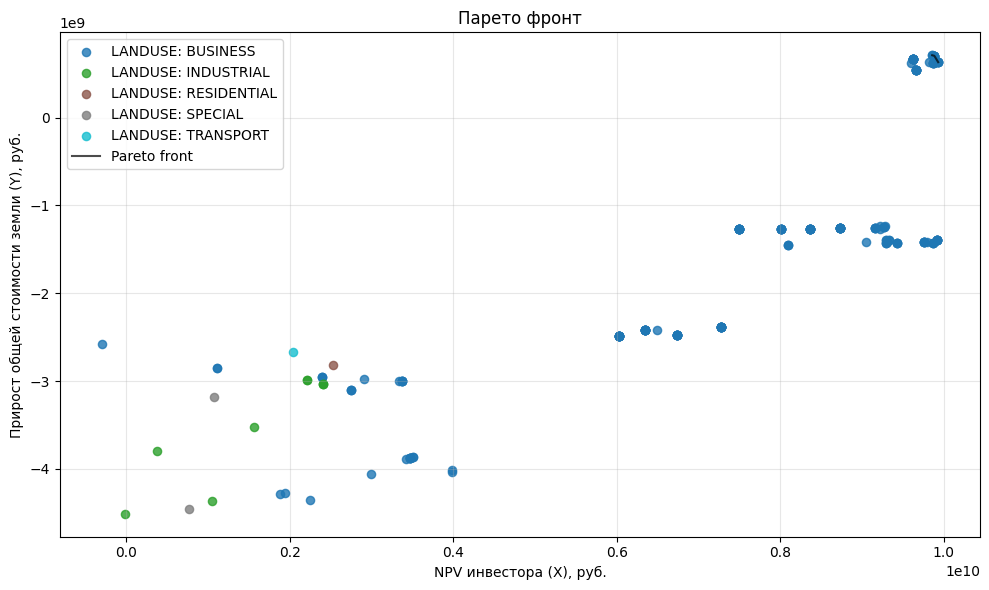

In [23]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem_moaed

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res_mpoead_no_llm, "history", None):
    for alg in res_mpoead_no_llm.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res_mpoead_no_llm.X)
    F = np.asarray(res_mpoead_no_llm.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res_mpoead_no_llm.F[:, 1]
pf_y = -res_mpoead_no_llm.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [21]:
from langchain_community.llms import Ollama
llm = Ollama(
    model="llama3",
    base_url="http://localhost:11434"
)
scorer = StrategicAlignmentScorer(llm=llm,
        strategic_goals="""
    Основные цели развития Гатчины — cосздание комфортной жилой застройки. 
    """,
        max_retries=2,)
res_mpoead_llm = optimize_moead_with_llm(problem, generations=50, population_size=30, strategic_alignment_scorer=scorer)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       66 |     12 |             - |             -
     2 |      132 |     36 |  1.017503E+02 |         ideal
     3 |      198 |     53 |  6.2673155901 |         ideal
     4 |      264 |     26 |  1.6367146823 |         ideal
     5 |      330 |     53 |  1.5849912107 |         ideal
     6 |      396 |     49 |  3.2329188300 |         ideal
     7 |      462 |     20 |  5.339822E+07 |         ideal
     8 |      528 |     29 |  0.9999039927 |         ideal
     9 |      594 |     34 |  0.1231897582 |         ideal
    10 |      660 |     43 |  0.1537227914 |         ideal
    11 |      726 |     36 |  0.3389444842 |         ideal
    12 |      792 |     53 |  0.2479186360 |         ideal
    13 |      858 |     11 |  2.527782E+01 |         ideal
    14 |      924 |     29 |  1.575759E+07 |         ideal
    15 |      990 |     40 |  0.9128639200 |         ideal
    16 |     1056 |     43 |  0.4314610589 |         ide

In [24]:
res_mpoead_llm[0]

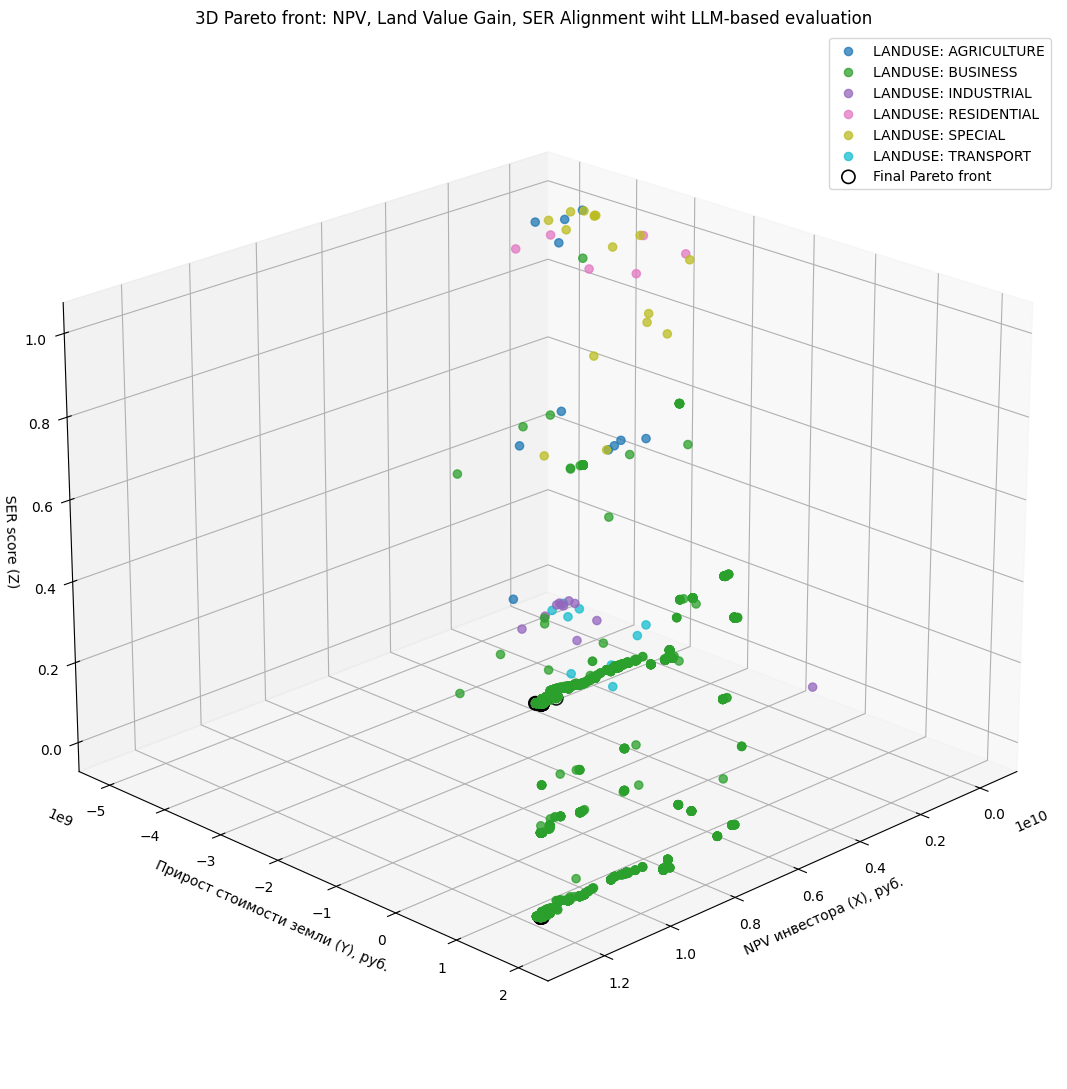

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res_mpoead_llm[0], "history", None):
    for alg in res_mpoead_llm[0].history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res_mpoead_llm[0].X)
    F = np.asarray(res_mpoead_llm[0].F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res_mpoead_llm[0].F[:, 1]
pf_y = -res_mpoead_llm[0].F[:, 0] - baseline_land_value
pf_z = -res_mpoead_llm[0].F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("SER score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment wiht LLM-based evaluation")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


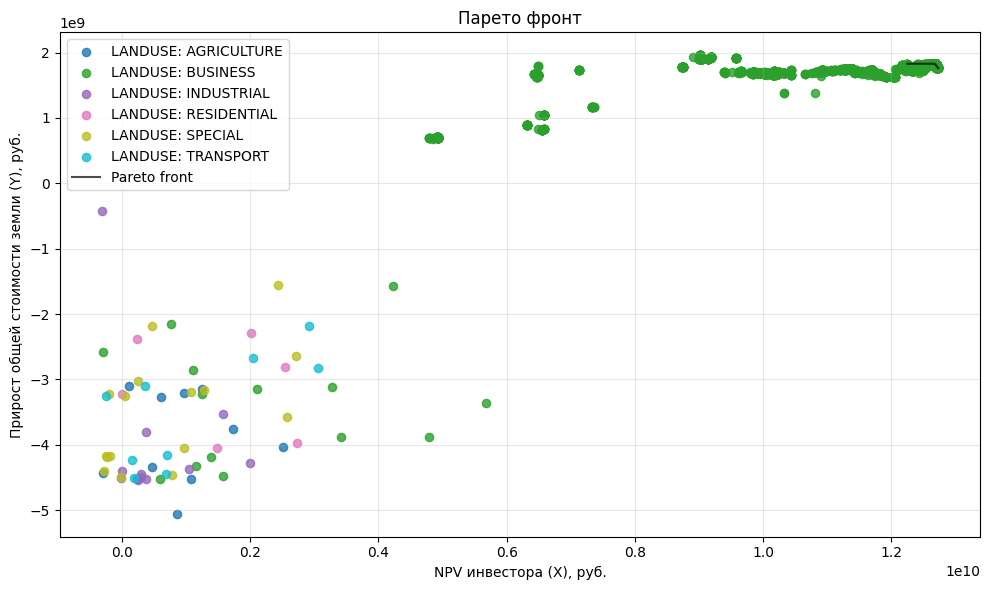

In [27]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res_mpoead_llm[0], "history", None):
    for alg in res_mpoead_llm[0].history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res_mpoead_llm[0].X)
    F = np.asarray(res_mpoead_llm[0].F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res_mpoead_llm[0].F[:, 1]
pf_y = -res_mpoead_llm[0].F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


## NSGA 3

In [17]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import (
    run_nsga3_with_strategic_alignment,
    
    optimize_nsga3_without_llm
    
    )
from urbanomy.methods.land_value_modeling import build_pareto_front_dataframe

In [ ]:



res_2, problem_2 = optimize_nsga3_without_llm(
    problem=problem,
    population_size=30,
    generations=50
)



n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       30 |      2 |             - |             -
     2 |       60 |      3 |  0.0512784632 |         ideal
     3 |       90 |      3 |  0.7635128434 |         ideal
     4 |      120 |      3 |  0.0784603646 |             f
     5 |      150 |      4 |  0.0262870482 |         ideal
     6 |      180 |      4 |  0.7825111283 |         ideal
     7 |      210 |      5 |  0.1041720706 |         ideal
     8 |      240 |      3 |  0.2093157975 |         ideal
     9 |      270 |      4 |  0.2635953813 |         ideal
    10 |      300 |      4 |  0.0709599505 |         ideal
    11 |      330 |      2 |  1.6056862703 |         ideal
    12 |      360 |      2 |  0.4500034429 |         ideal
    13 |      390 |      4 |  0.2528369832 |         ideal
    14 |      420 |      3 |  0.0197496362 |         ideal
    15 |      450 |      2 |  0.0765738878 |         ideal
    16 |      480 |      5 |  0.2639944664 |            

In [29]:
df_pareto_2 = build_pareto_front_dataframe(res=res_2, problem=problem)
df_pareto_2

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired
0,scenario_0,scenario_0 | BUSINESS,scenario_0 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.464065e+10,1.689128e+09,1.144300e+10,"{'footprint_area': 33072.63093225142, 'l': 9.9..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.530250e+10,2.350984e+09,1.020694e+10,"{'footprint_area': 32973.19916266263, 'l': 9.9..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.526885e+10,2.317329e+09,1.060727e+10,"{'footprint_area': 33054.741134304495, 'l': 9...."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.521907e+10,2.267551e+09,1.074744e+10,"{'footprint_area': 33053.03074876544, 'l': 9.9..."
4,scenario_4,scenario_4 | BUSINESS,scenario_4 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.466640e+10,1.714882e+09,1.118992e+10,"{'footprint_area': 33088.77509054125, 'l': 9.9..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.490123e+10,1.949713e+09,1.106184e+10,"{'footprint_area': 33063.73766584067, 'l': 9.9..."


In [18]:
problem

In [18]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ['PATH']}"

load_dotenv()

#llm = ChatOpenAI(
#    model=os.getenv("CHAT_MODEL"),
#    base_url=os.getenv("BASE_URL") + "/v1",
#    temperature=float(os.getenv("TEMPERATURE", "0")),
#    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
#)

from langchain_community.llms import Ollama

llm = Ollama(
    model="llama3",
    base_url="http://localhost:11434"
)

from urbanomy.methods.land_value_modeling import (
    run_nsga3_with_strategic_alignment,
    build_pareto_front_dataframe,
    
    )
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import run_nsga2_without_strategic_alignment


constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}


res, problem, history = run_nsga3_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    
    },
    return_pareto_prompt_history=True,
    constraints=constraints,
    target_id=target_id,
    llm=llm,
    strategic_goals={
        'environmental': 'Цель - минимизировать негативное воздействие на окружающую среду, сохраняя при этом баланс с экономическими и социальными факторами.',
        'economic': 'Цель - способствовать экономическому росту и развитию инфраструктуры.',
        'social': 'Цель - обеспечивать высокое качество жизни для жителей.'
    },
    pop_size=1,
    n_gen=1,
    seed=42,
    verbose=True,
    save_history=True,
)


pareto_df = build_pareto_front_dataframe(res=res, problem=problem)

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_64421/1192342269.py:18: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |        5 |      2 |             - |             -


In [19]:
print(problem.n_obj)
print(problem.objective_names)

5
['land_value_total', 'investor_npv', 'ser_alignment_environmental', 'ser_alignment_economic', 'ser_alignment_social']


In [20]:
pareto_df

,scenario_id,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_environmental,ser_alignment_environmental_reasoning,ser_alignment_economic,ser_alignment_economic_reasoning,ser_alignment_social,ser_alignment_social_reasoning,ser_alignment_mean,title,summary
0,scenario_0,RECREATION,5.883365e+10,-4.117873e+09,1.192591e+09,"{'footprint_area': 25612.109066844827, 'l': 4....",1.0,Сценарий соответствует целям социально-экономи...,1.0,Сценарий соответствует целям социально-экономи...,1.0,Сценарий соответствует целям социально-экономи...,1.000000,scenario_0 | RECREATION,"land value gain=-4,117,872,974 | npv=1,192,591..."
1,scenario_1,BUSINESS,6.061385e+10,-2.337667e+09,1.659104e+09,"{'footprint_area': 14466.432100154389, 'l': 8....",0.5,Оценка была проведена на основе данных о земел...,0.9,Сценарий соответствует целям социально-экономи...,0.5,Сценарий частично соответствует целям социальн...,0.633333,scenario_1 | BUSINESS,"land value gain=-2,337,667,139 | npv=1,659,104..."


In [27]:
df_hist = pd.DataFrame(history)
df_hist['prompt'][0]

'Ты градостроительный эксперт. Оцени, насколько сценарий соответствует целям социально-экономического развития.\nВерни только JSON без markdown в формате:\n{"score": 0.0, "reasoning": "краткое объяснение на русском"}\n\nПравила:\n- 0.0 означает, что сценарий противоречит целям.\n- 0.5 означает частичное соответствие.\n- 1.0 означает максимально сильное соответствие.\n- Используй только данные из сценария.\n- В reasoning укажи 1-3 причины оценки.\n\nЦели СЭР:\nЦель - минимизировать негативное воздействие на окружающую среду, сохраняя при этом баланс с экономическими и социальными факторами.\n\nСценарий:\n{\n  "target_id": 7,\n  "site_area": 330924.5933878487,\n  "land_use": "RECREATION",\n  "land_value_after": 58833646939.24995,\n  "investor_npv": 1192591257.37,\n  "params_repaired": {\n    "footprint_area": 25612.109066844827,\n    "l": 4.949905957768471,\n    "mxi": 0.1433118074895298,\n    "residential": 0.17913975936191223,\n    "business": 0.02419225822653892,\n    "recreation": 0.

In [28]:
pareto_df['ser_alignment_environmental_reasoning'][0]

'Сценарий соответствует целям социально-экономического развития, поскольку в сценарии указана рекреационная зона, что не имеет отрицательного влияния на окружающую среду и при этом обеспечивает экономические и социальные факторы.'

In [34]:
results = []
for i in range(pareto_df.shape[0]):
        results.append({
            'problem': df_hist['prompt'][i],
            'model': 'llama3',
            'solution': pareto_df['ser_alignment_environmental_reasoning'][i]
        })
results

[{'problem': 'Ты градостроительный эксперт. Оцени, насколько сценарий соответствует целям социально-экономического развития.\nВерни только JSON без markdown в формате:\n{"score": 0.0, "reasoning": "краткое объяснение на русском"}\n\nПравила:\n- 0.0 означает, что сценарий противоречит целям.\n- 0.5 означает частичное соответствие.\n- 1.0 означает максимально сильное соответствие.\n- Используй только данные из сценария.\n- В reasoning укажи 1-3 причины оценки.\n\nЦели СЭР:\nЦель - минимизировать негативное воздействие на окружающую среду, сохраняя при этом баланс с экономическими и социальными факторами.\n\nСценарий:\n{\n  "target_id": 7,\n  "site_area": 330924.5933878487,\n  "land_use": "RECREATION",\n  "land_value_after": 58833646939.24995,\n  "investor_npv": 1192591257.37,\n  "params_repaired": {\n    "footprint_area": 25612.109066844827,\n    "l": 4.949905957768471,\n    "mxi": 0.1433118074895298,\n    "residential": 0.17913975936191223,\n    "business": 0.02419225822653892,\n    "re

In [ ]:
import json

def read_json(file_path : str) -> list | dict:
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
def write_json(data : dict, file_path : str):
    with open(file_path, "w") as f:
        json.dump(data, f)
write_json(results, 'fp2mp-eval/examples/data/results.json')

In [26]:
from fp2mp_eval import FP2MPEval
N_JUDGES = 5

fp2mp = FP2MPEval(model='llama3', n_judges=N_JUDGES)

In [33]:
evaluations = {}
for i in range(pareto_df.shape[0]):
    evals = fp2mp.evaluate_case((df_hist['prompt'][i], pareto_df['ser_alignment_environmental_reasoning'][i]), max_workers=N_JUDGES)
    evaluations[i] = evals

  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [31]:
evaluations[0]

[Evaluation(framing=Dimension(score=4, evidence='The solution does not provide a detailed analysis of the impact on the environment. However, it is stated that the recreation area has no negative influence on the environment, which suggests some thought was given to sustainability.', commentary='While the solution mentions the positive environmental aspects, it could be improved by providing more specific data and metrics to support its claims. Overall, a good effort, but with room for improvement.'), decomposition=Dimension(score=4, evidence='The decomposition of land use is provided, which shows that recreation is the dominant land use. This suggests that the scenario does prioritize environmental concerns.', commentary='However, the decomposition could be more detailed and include specific metrics to quantify the impact.'), diversity=Dimension(score=4, evidence='The scenario does provide some diversity in terms of land use, with a mix of recreation and other uses. This suggests that

In [ ]:
from fp2mp_eval.models import Evaluation
from fp2mp_eval import FP2MPEval
import pingouin as pg

ev = Evaluation(

In [80]:
res_2, problem_2 = run_nsga2_without_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    pop_size=30,
    n_gen=50,
    seed=42,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       30 |      5 |             - |             -
     2 |       60 |      5 |  0.1515034311 |         ideal
     3 |       90 |      4 |  0.0978467579 |         ideal
     4 |      120 |      6 |  0.0782461145 |             f
     5 |      150 |      8 |  0.0065436548 |         ideal
     6 |      180 |      3 |  1.0317795644 |         ideal
     7 |      210 |      5 |  0.1766584512 |         ideal
     8 |      240 |      7 |  0.0194615164 |         ideal
     9 |      270 |     12 |  0.1088109587 |         ideal
    10 |      300 |      4 |  0.0313819525 |         ideal
    11 |      330 |      5 |  0.0715411798 |         ideal
    12 |      360 |      6 |  0.1185666689 |         ideal
    13 |      390 |      8 |  0.1324769370 |         ideal
    14 |      420 |      5 |  0.1192801979 |         ideal
    15 |      450 |      6 |  0.1650692116 |         ideal
    16 |      480 |      4 |  0.2384402836 |         ide

In [ ]:
print(pareto_df['investor_npv'].mean())
print(pareto_df['ser_alignment_score'].mean())
print(pareto_df['land_value_gain'].mean())


10464129264.698002
0.86
1970685039.037497


In [43]:
df_pareto_2

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,score
0,scenario_0,scenario_0 | BUSINESS,scenario_0 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.464065e+10,1.689128e+09,1.144300e+10,"{'footprint_area': 33072.63093225142, 'l': 9.9...","{'score': 0.5, 'reasoning': 'В сценарии предус...",0.5
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.530250e+10,2.350984e+09,1.020694e+10,"{'footprint_area': 32973.19916266263, 'l': 9.9...","{'score': 1.0, 'reasoning': 'Сценарий соответс...",1.0
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.526885e+10,2.317329e+09,1.060727e+10,"{'footprint_area': 33054.741134304495, 'l': 9....","{'score': 1.0, 'reasoning': 'Сценарий соответс...",1.0
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.521907e+10,2.267551e+09,1.074744e+10,"{'footprint_area': 33053.03074876544, 'l': 9.9...","{'score': 1.0, 'reasoning': 'Сценарий соответс...",1.0
4,scenario_4,scenario_4 | BUSINESS,scenario_4 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.466640e+10,1.714882e+09,1.118992e+10,"{'footprint_area': 33088.77509054125, 'l': 9.9...","{'score': 0.5, 'reasoning': 'Сценарий не соотв...",0.5
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.490123e+10,1.949713e+09,1.106184e+10,"{'footprint_area': 33063.73766584067, 'l': 9.9...","{'score': 1.0, 'reasoning': 'Сценарий полность...",1.0


In [81]:
#оценка сэр для датафрейма без стратегической оптимизации
pareto_df_2 = build_pareto_front_dataframe(res=res_2, problem=problem_2)
pareto_df_2

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired
0,scenario_0,scenario_0 | BUSINESS,scenario_0 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.465201e+10,1.700494e+09,1.149518e+10,"{'footprint_area': 33084.71770026332, 'l': 9.9..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.536029e+10,2.408771e+09,1.046354e+10,"{'footprint_area': 33086.67992162374, 'l': 9.9..."
2,scenario_2,scenario_2 | BUSINESS,scenario_2 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.470248e+10,1.750962e+09,1.122035e+10,"{'footprint_area': 32784.81981153979, 'l': 9.9..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.493186e+10,1.980341e+09,1.111243e+10,"{'footprint_area': 33086.23474401348, 'l': 9.9..."
4,scenario_4,scenario_4 | RESIDENTIAL,scenario_4 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.498462e+10,2.033098e+09,1.098590e+10,"{'footprint_area': 33086.140914002, 'l': 9.994..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.510174e+10,2.150218e+09,1.084096e+10,"{'footprint_area': 33085.394071991024, 'l': 9...."
6,scenario_6,scenario_6 | RESIDENTIAL,scenario_6 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.526421e+10,2.312692e+09,1.079249e+10,"{'footprint_area': 33085.990196137405, 'l': 9...."
7,scenario_7,scenario_7 | RESIDENTIAL,scenario_7 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.510757e+10,2.156055e+09,1.080722e+10,"{'footprint_area': 33085.394071991024, 'l': 9...."
8,scenario_8,scenario_8 | RESIDENTIAL,scenario_8 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.535448e+10,2.402959e+09,1.051981e+10,"{'footprint_area': 33085.39341038386, 'l': 9.9..."
9,scenario_9,scenario_9 | BUSINESS,scenario_9 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.469288e+10,1.741360e+09,1.136244e+10,"{'footprint_area': 33086.041182738096, 'l': 9...."


In [37]:
df_pareto_2['ser_alignment_score'] = df_pareto_2.apply(
    lambda row: problem.evaluate_strategic_alignment(
        params_repaired=row['params_repaired'],
        land_value_after=row['land_value_after'],
        investor_npv=row['investor_npv'],
    ),
    axis=1
)
df_pareto_2['score'] = df_pareto_2['ser_alignment_score'].apply(
    lambda x: x.get('score') if isinstance(x, dict) else None
)

In [44]:
10464129264/df_pareto_2['investor_npv'].mean()


np.float64(0.9621242452109605)

In [ ]:
df_pareto_2['score'].mean()

np.float64(0.8333333333333334)

In [45]:
1970685039/df_pareto_2['land_value_gain'].mean()

np.float64(0.9621242510390382)

In [19]:
pareto_df['ser_alignment_reasoning'].dropna().tolist()

['Сценарий частично соответствует целям социально-экономического развития Гатчины, так как он предусматривает строительство бизнес-центра, что не напрямую связано с созданием комфортной жилой застройки. В то же время, проект может иметь положительные последствия для развития города в целом.',
 'Сценарий полностью соответствует целям социально-экономического развития Гатчины, учитывая создание комфортной жилой застройки.']

In [116]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.520592e+10,2.254403e+09,9.689464e+09,"{'footprint_area': 32430.496670509016, 'l': 9....",0.8,Сценарий частично соответствует целям социальн...
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.519586e+10,2.244342e+09,9.934796e+09,"{'footprint_area': 33068.60940153923, 'l': 9.9...",1.0,Сценарий соответствует целям социально-экономи...
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.493773e+10,1.986214e+09,1.069847e+10,"{'footprint_area': 32951.31310974595, 'l': 9.9...",1.0,Сценарий соответствует целям создания эффектив...
3,scenario_3,scenario_3 | BUSINESS,scenario_3 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.464458e+10,1.693057e+09,1.099280e+10,"{'footprint_area': 32995.329972406405, 'l': 9....",0.5,Сценарий частично соответствует целям социальн...
4,scenario_4,scenario_4 | BUSINESS,scenario_4 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.462693e+10,1.675409e+09,1.100511e+10,"{'footprint_area': 32783.96971169814, 'l': 9.9...",1.0,Сценарий соответствует целям социально-экономи...


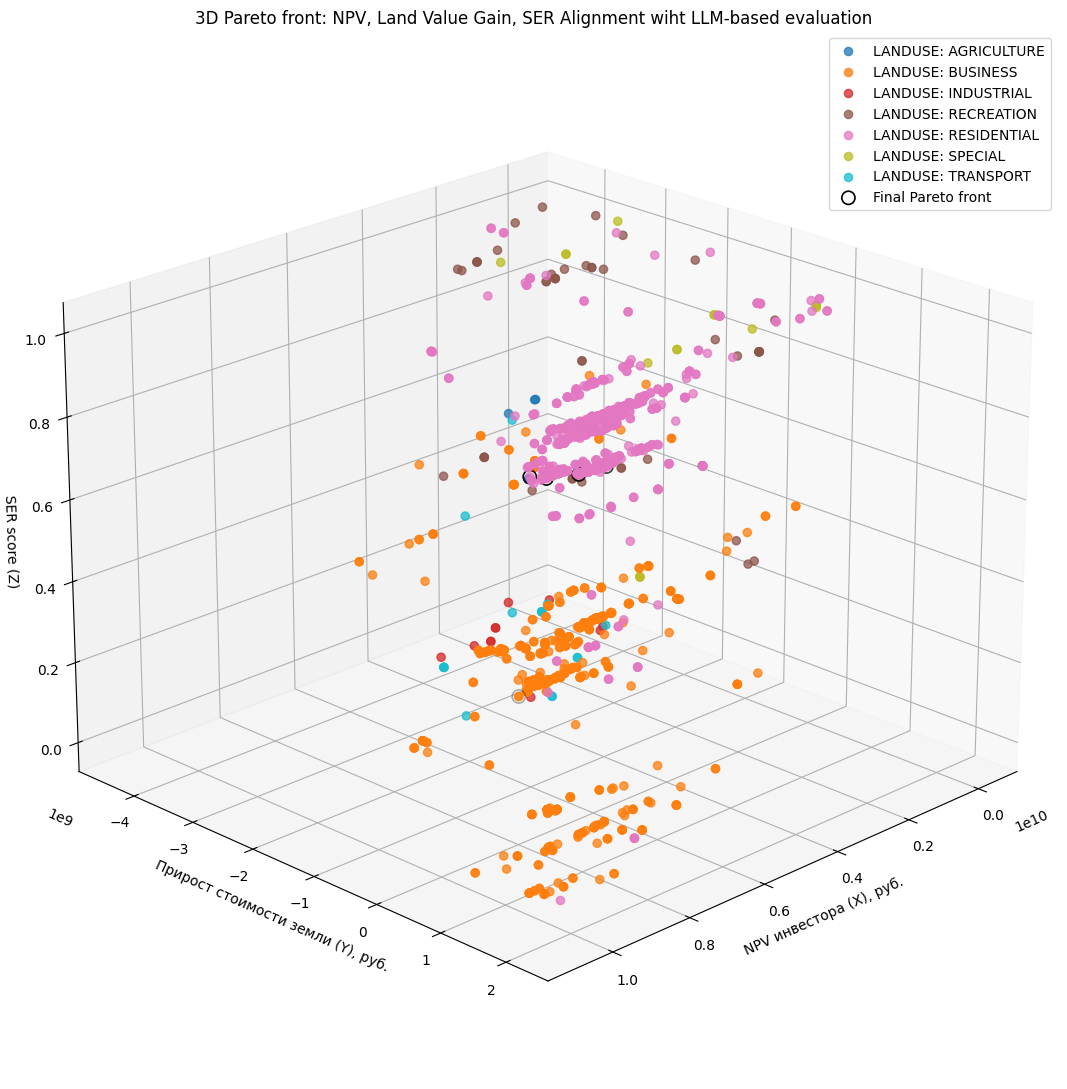

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("SER score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment wiht LLM-based evaluation")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


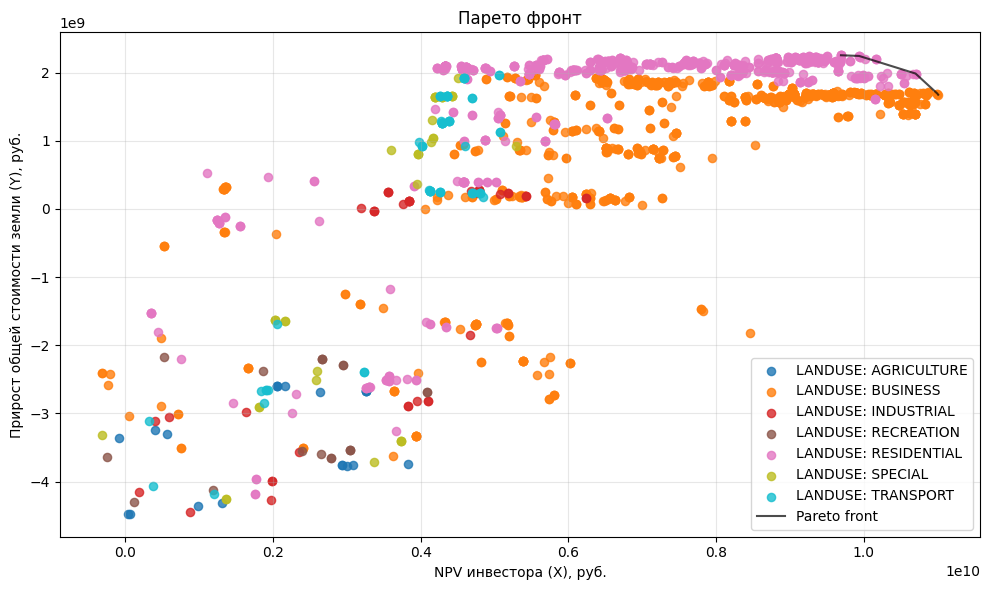

In [112]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


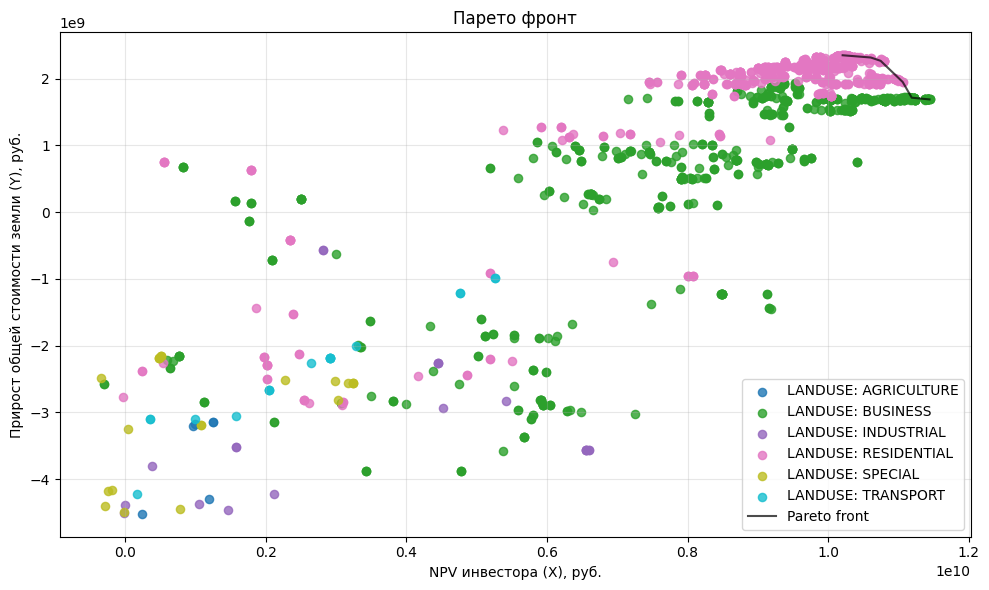

In [42]:
#Парето-фронт без llm
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res_2, "history", None):
    for alg in res_2.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res_2.X)
    F = np.asarray(res_2.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res_2.F[:, 1]
pf_y = -res_2.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [ ]:
# Оптимизируем без использования LLM, просто NSGA-III с теми же целями и ограничениями, для сравнения
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
problem = DistrictProblem(
    blocks=blocks_clean,
    target_id=target_id,
    model=model,   
    constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    })
algorithm = NSGA3(pop_size=10, seed=42, ref_dirs=)
res_nsga3 = minimize(problem, algorithm, ("n_gen", 10), verbose=True)


TypeError: NSGA3.__init__() missing 1 required positional argument: 'ref_dirs'

## NSGA 2

In [17]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ['PATH']}"

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)


constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}




from urbanomy.methods.land_value_modeling import (
    run_nsga2_with_strategic_alignment,
    build_pareto_front_dataframe,
)

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    llm=llm,
    strategic_goals="""
    Основные цели развития Гатчины — создание комфортной жилой застройки.
    """,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      5 |             - |             -
     2 |       40 |     10 |  0.3653456387 |         nadir
     3 |       60 |      5 |  0.2228740856 |         ideal
     4 |       80 |      7 |  0.3668325201 |         ideal
     5 |      100 |     12 |  0.0778862652 |         ideal
     6 |      120 |      1 |  1.004325E+09 |         ideal
     7 |      140 |      3 |  1.0000000000 |         ideal
     8 |      160 |      6 |  0.3686151989 |         ideal
     9 |      180 |      9 |  0.0753321188 |         ideal
    10 |      200 |     10 |  0.0338706698 |         ideal
    11 |      220 |     14 |  0.0937099665 |         ideal
    12 |      240 |      3 |  0.0950760722 |         ideal
    13 |      260 |      6 |  0.2755481277 |         ideal
    14 |      280 |      3 |  4.8357844359 |         nadir
    15 |      300 |      7 |  0.0288127492 |         ideal
    16 |      320 |      5 |  0.0066390996 |         ide

In [21]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365665e+10,7.051281e+08,7.342845e+09,"{'footprint_area': 26153.17730599988, 'l': 9.9...",0.5,"Сценарий объявлен жилым, но только 43% площади..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365459e+10,7.030661e+08,7.345671e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.3,"Жилой участок составляет лишь 43% площади, а з..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.380163e+10,8.501151e+08,6.645767e+09,"{'footprint_area': 26218.515324245953, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 41..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371507e+10,7.635452e+08,7.111336e+09,"{'footprint_area': 26136.385033216895, 'l': 9....",0.3,"Хотя земельный участок отнесён к жилому, тольк..."
4,scenario_4,scenario_4 | RESIDENTIAL,scenario_4 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.377410e+10,8.225807e+08,6.851889e+09,"{'footprint_area': 26154.983702396923, 'l': 9....",0.5,"Хотя участок отнесён к жилой категории, только..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.366827e+10,7.167528e+08,7.333057e+09,"{'footprint_area': 26136.816596057815, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но т..."
6,scenario_6,scenario_6 | RESIDENTIAL,scenario_6 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.368393e+10,7.324115e+08,7.237215e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.5,"Сценарий объявлен жилым, но только 44,8% площа..."
7,scenario_7,scenario_7 | RESIDENTIAL,scenario_7 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371177e+10,7.602462e+08,6.896353e+09,"{'footprint_area': 26136.435369611885, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 40..."
8,scenario_8,scenario_8 | RESIDENTIAL,scenario_8 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.367883e+10,7.273117e+08,7.243238e+09,"{'footprint_area': 26152.732635511984, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 42..."
9,scenario_9,scenario_9 | RESIDENTIAL,scenario_9 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365816e+10,7.066380e+08,7.335286e+09,"{'footprint_area': 26167.469326830047, 'l': 9....",0.4,"Сценарий заявлен как RESIDENTIAL, но только 43..."


In [18]:
pareto_df['ser_alignment_reasoning'].dropna().tolist()

['Сценарий объявлен жилым, но только 43% площади отведено под жильё, значительная часть – бизнес, промышленность и транспорт – противоречит цели комфортной жилой застройки; при этом тип застройки (высотный советский микрорайон) не гарантирует высокий уровень комфорта.',
 'Жилой участок составляет лишь 43% площади, а значительная часть отведена под бизнес (38%) и промышленность (13%). Плотность населения низкая (≈4,5 тыс. человек на 262\u202fтыс.\u202fм²) и доминирует тип застройки «высотный советский микрорайон», что не способствует созданию комфортной жилой среды.',
 'Сценарий заявлен как RESIDENTIAL, но только 41% площади отведено под жильё, остальные значительные доли – бизнес, промышленность и транспорт, что снижает комфортность. Кроме того, тип «high-rise soviet microdistrict» обычно не соответствует современным требованиям комфортного жилья.',
 'Хотя земельный участок отнесён к жилому, только 40% площади отведено под жильё, а значительная часть – под бизнес (35%) и промышленность

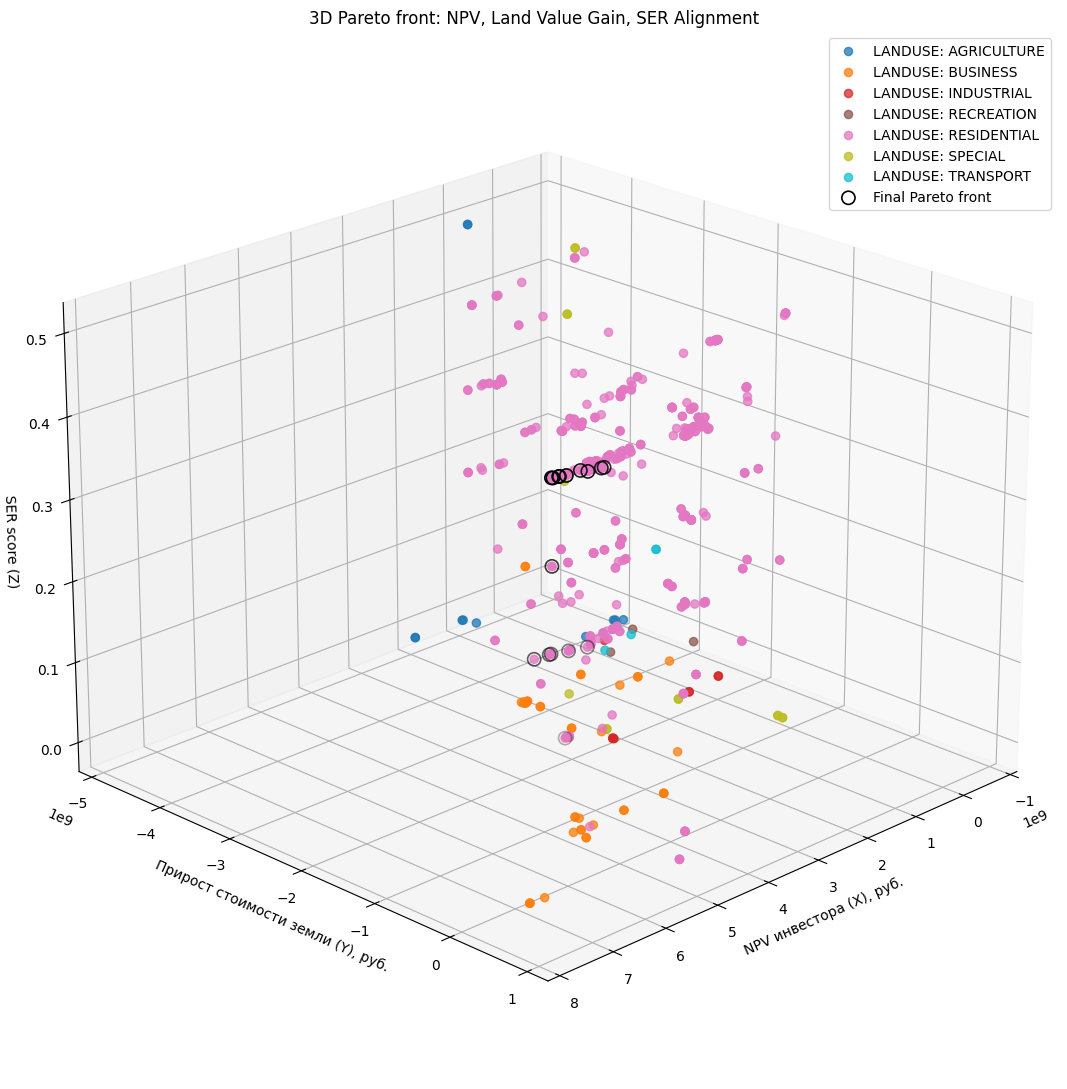

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("SER score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


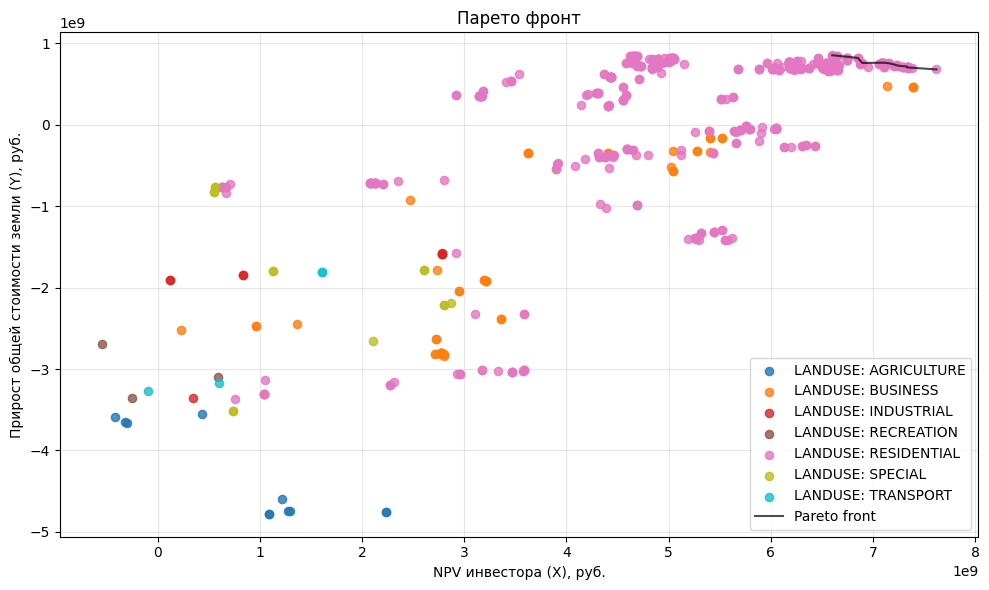

In [20]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

# NSGA 2(2 критерия)

In [17]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 30),
    seed=42,
    verbose=True,
    save_history=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      2 |             - |             -
     2 |       40 |      4 |  0.0290188786 |             f
     3 |       60 |      7 |  0.1993080825 |         ideal
     4 |       80 |      4 |  0.0816176823 |         ideal
     5 |      100 |      2 |  1.0064494217 |         ideal
     6 |      120 |      2 |  1.844033E+01 |         ideal
     7 |      140 |      2 |  0.9756397487 |         ideal
     8 |      160 |      2 |  0.2794573753 |         ideal
     9 |      180 |      5 |  0.8232373236 |         ideal
    10 |      200 |      3 |  0.7092275666 |         ideal
    11 |      220 |      9 |  0.0071206440 |         ideal
    12 |      240 |      7 |  0.0499500510 |         ideal
    13 |      260 |      8 |  0.1214455105 |         ideal
    14 |      280 |      6 |  0.1060155591 |         ideal
    15 |      300 |      5 |  0.3778818222 |         ideal
    16 |      320 |      4 |  0.3672532208 |         ide

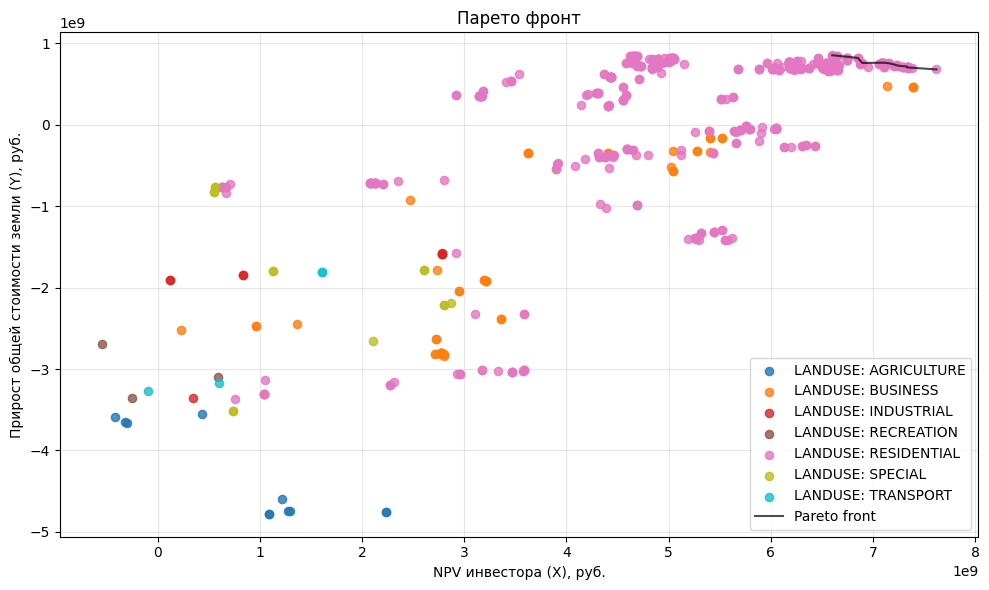

In [24]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [29]:
from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
)

pareto_front_df = build_pareto_front_dataframe(
    res=res,
    problem=problem,
    use_history=False,                        # True если хочешь взять все решения из history
    scenario_prefix="scenario",
)
pareto_front_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365665e+10,7.051281e+08,7.342845e+09,"{'footprint_area': 26153.17730599988, 'l': 9.9...",0.5,"Сценарий объявлен жилым, но только 43% площади..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365459e+10,7.030661e+08,7.345671e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.3,"Жилой участок составляет лишь 43% площади, а з..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.380163e+10,8.501151e+08,6.645767e+09,"{'footprint_area': 26218.515324245953, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 41..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371507e+10,7.635452e+08,7.111336e+09,"{'footprint_area': 26136.385033216895, 'l': 9....",0.3,"Хотя земельный участок отнесён к жилому, тольк..."
4,scenario_4,scenario_4 | RESIDENTIAL,scenario_4 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.377410e+10,8.225807e+08,6.851889e+09,"{'footprint_area': 26154.983702396923, 'l': 9....",0.5,"Хотя участок отнесён к жилой категории, только..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.366827e+10,7.167528e+08,7.333057e+09,"{'footprint_area': 26136.816596057815, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но т..."
6,scenario_6,scenario_6 | RESIDENTIAL,scenario_6 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.368393e+10,7.324115e+08,7.237215e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.5,"Сценарий объявлен жилым, но только 44,8% площа..."
7,scenario_7,scenario_7 | RESIDENTIAL,scenario_7 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371177e+10,7.602462e+08,6.896353e+09,"{'footprint_area': 26136.435369611885, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 40..."
8,scenario_8,scenario_8 | RESIDENTIAL,scenario_8 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.367883e+10,7.273117e+08,7.243238e+09,"{'footprint_area': 26152.732635511984, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 42..."
9,scenario_9,scenario_9 | RESIDENTIAL,scenario_9 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365816e+10,7.066380e+08,7.335286e+09,"{'footprint_area': 26167.469326830047, 'l': 9....",0.4,"Сценарий заявлен как RESIDENTIAL, но только 43..."


In [19]:
# print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
# print("Значения целевых функций:\n", -res.F)


In [26]:
len(res.opt)

16

In [21]:
# params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
# params_optimal

In [24]:
idx = np.argmin(res.F[:, 0])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

NameError: name 'res' is not defined

In [25]:
idx = np.argmin(res_mpoead_no_llm.F[:, 1])   # максимум land_value

params_optimal = {p: res_mpoead_no_llm.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res_mpoead_no_llm.F[idx, 0]),
    "land_value_gain": float(-res_mpoead_no_llm.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res_mpoead_no_llm.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 32886.993398825354,
  'l': 9.441052322518459,
  'mxi': 0.2646805229975349,
  'residential': 0.33085065374691863,
  'business': 0.5426862854895657,
  'industrial': 0.10410604855309177,
  'transport': 0.00013893188888902284,
  'special': 0.016794187731149792,
  'agriculture': 0.005423892590385228,
  'recreation': 0.0,
  'share': 0.33085065374691863,
  'land_use': <LandUse.BUSINESS: 'business'>,
  'build_floor_area': 310487.8254086293,
  'living_area': 82180.08001352331,
  'non_living_area': 228307.745395106,
  'population': 4109.004000676166,
  'fsi': 0.9382434295076184,
  'gsi': 0.09937911553246602,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 63582957281.08198,
 'land_value_gain': 631437367.3930435,
 'investor_npv': 9932387638.26}

# Визуализация прироста стоимости земли

Price change after scenario:
 • Summ before:    62 951 519 914 ₽
 • Summ after: 63 582 957 281 ₽
 • Diff.  ₽:     +631 437 367 ₽
 • Diff., %:     +1.00%

Changable district:
 • Before: 374 723 309 ₽ | After: 632 450 013 ₽ | Δ: +257 726 704 ₽ | Δ%: +68.78%


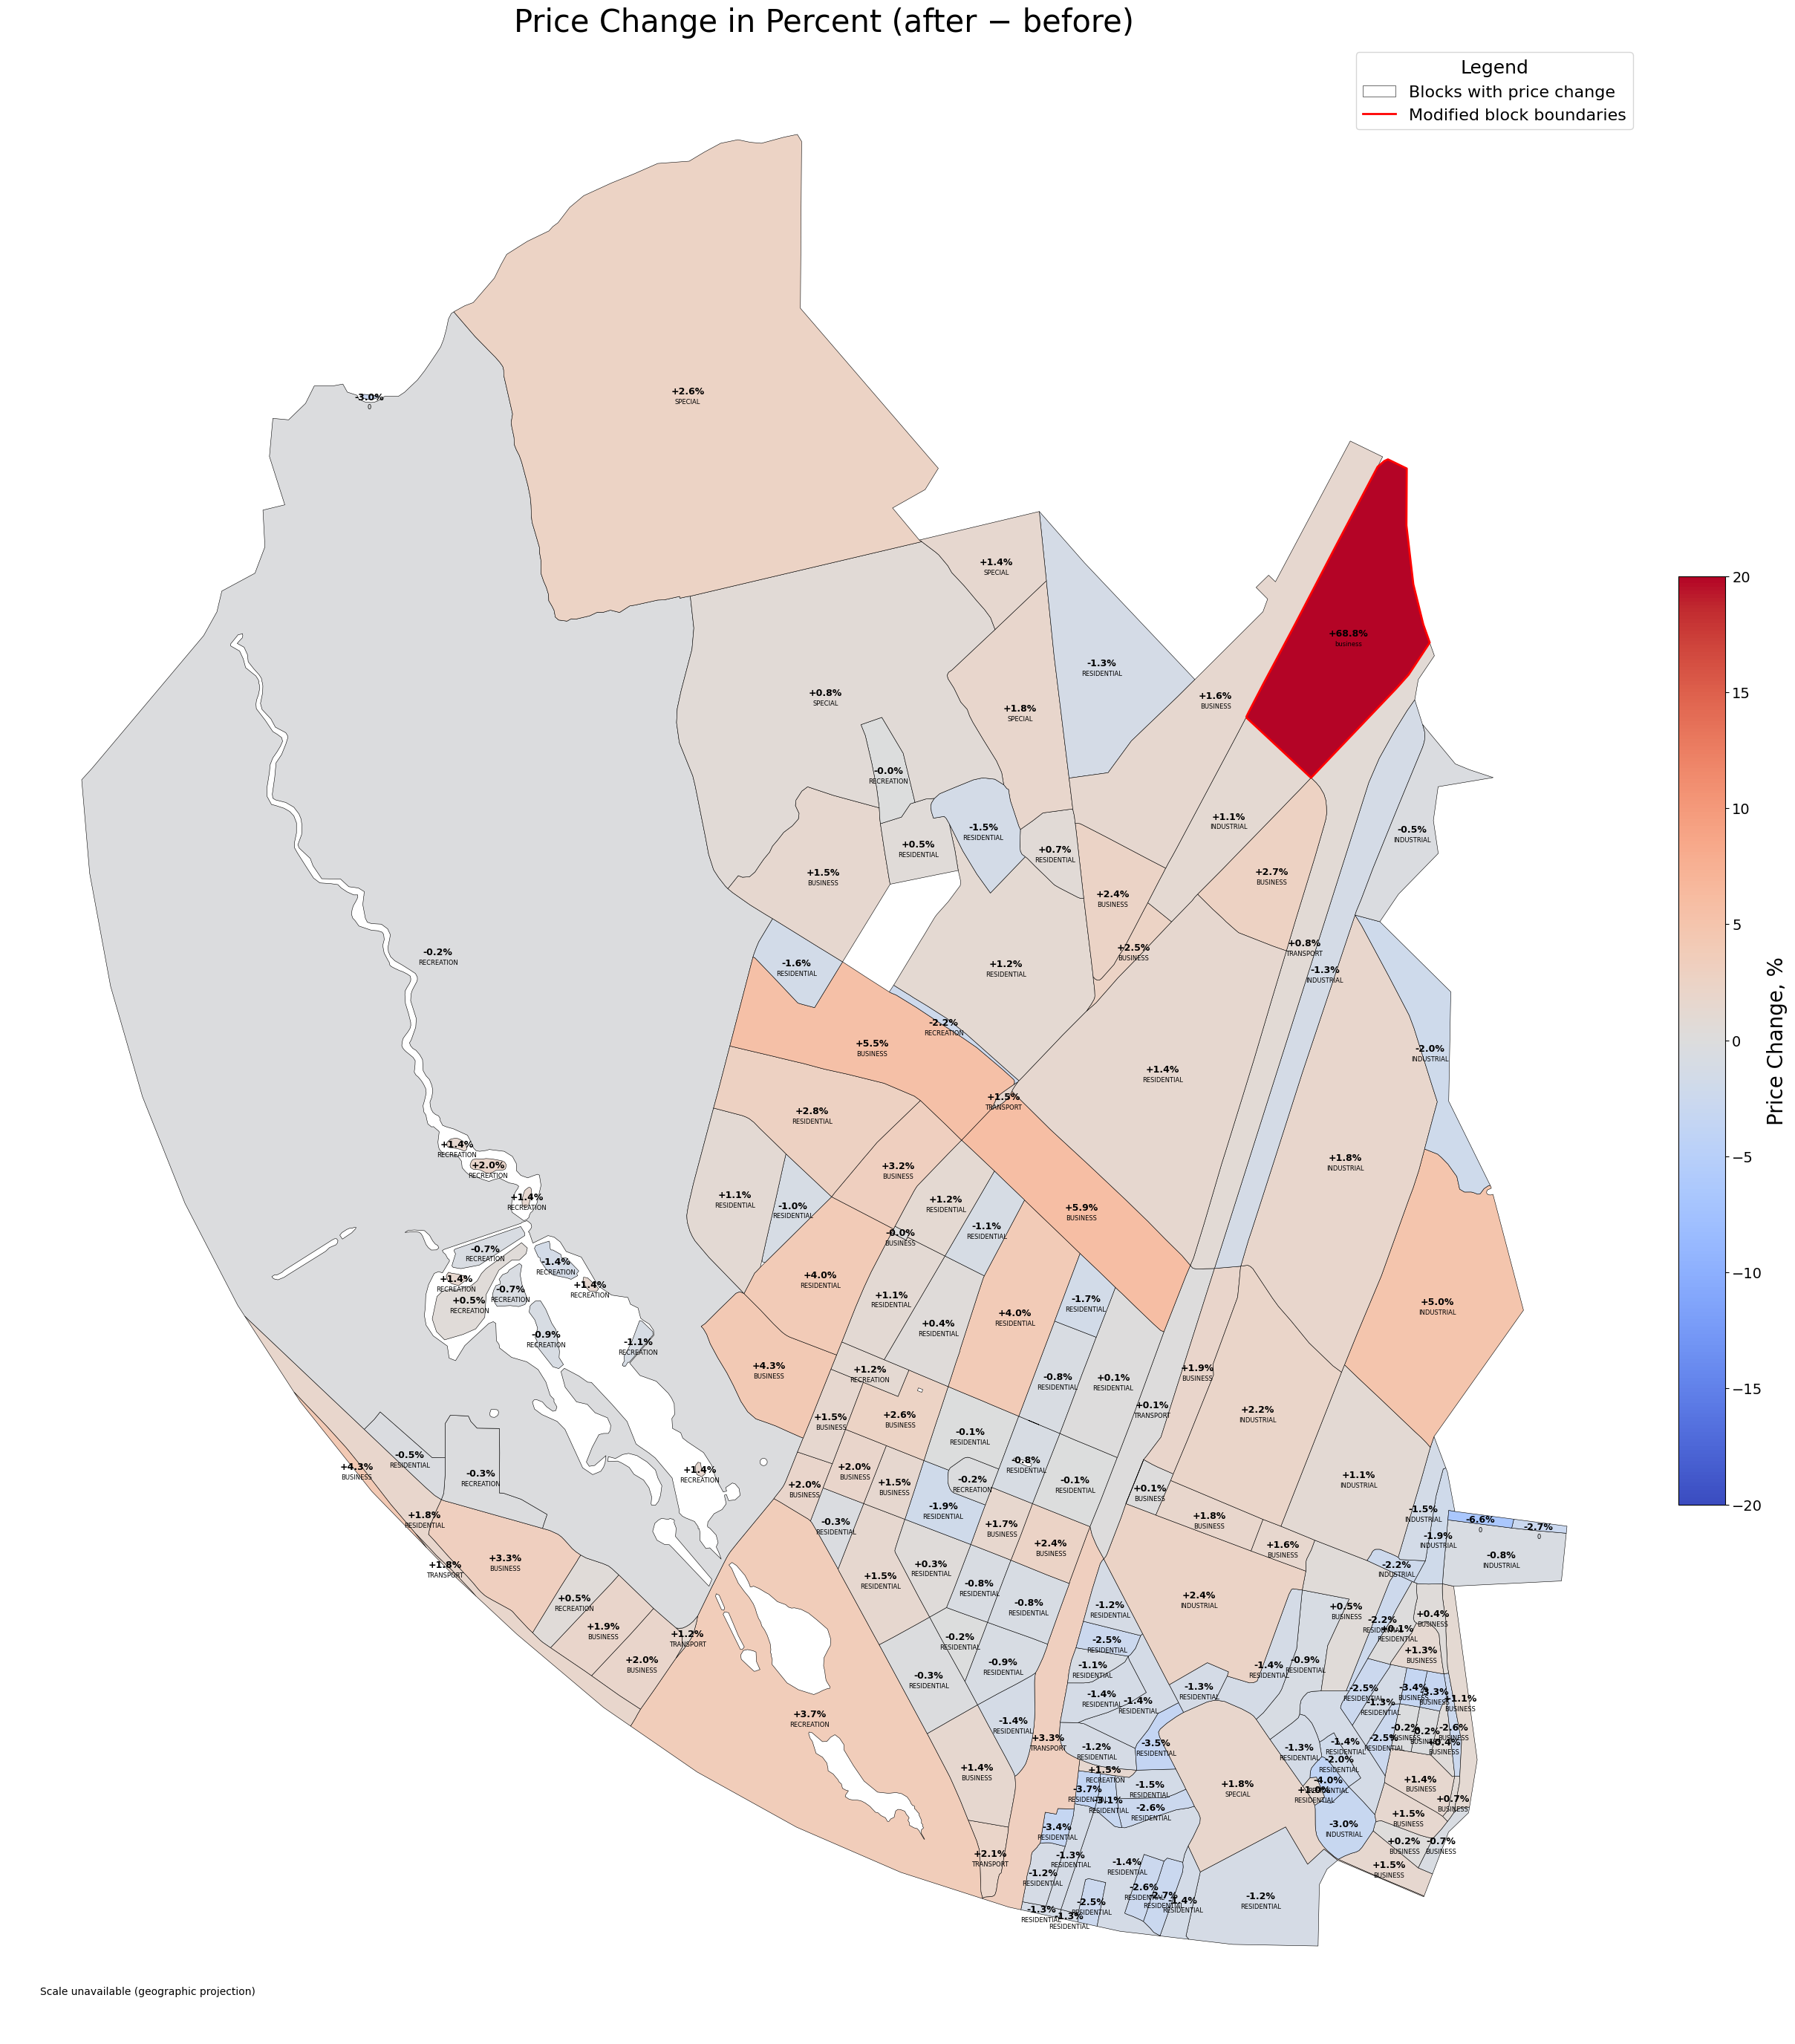

In [26]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Price change after scenario:")
print(f" • Summ before:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Summ after: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Diff., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Diff., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nChangable district:")
print(
    f" • Before: {target_row['land_value_before']:,.0f} ₽ | "
    f"After: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)



# Инвестиционная привлекательность

In [23]:
blocks_full_value.loc[blocks_full_value["id"] == 86].iloc[0]

residential                                                             0.996658
business                                                                0.003342
recreation                                                                   0.0
industrial                                                                   0.0
transport                                                                    0.0
special                                                                      0.0
agriculture                                                                  0.0
land_use                                                     LandUse.RESIDENTIAL
share                                                                   0.996658
footprint_area                                                      26168.673099
build_floor_area                                                    261609.12262
living_area                                                        208587.863272
non_living_area             

In [24]:
from urbanomy.methods.investment_potential import calculate_investment_metrics

summary = calculate_investment_metrics(blocks_full_value)
summary.head()

Project totals:
 • Land area:          262,250.98
 • Built area:         261,609.12
 • Land value:         590,959,314.48
 • Demolition cost:    96,396,921.16
 • Construction cost:  12,302,623,111.36
 • Investment need:    12,989,979,347.01
 • Project NPV:        7,264,713,973.68
 • Project IRR:        0.34
 • Project PI:         1.65
 • Project PP (yrs):   5.46


,land_use,land_area,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,PI,PP_years,EI
0,LandUse.RESIDENTIAL,262250.98,261609.12,5.909593e+08,96396921.16,1.230262e+10,1.298998e+10,7.264714e+09,0.34,1.65,5.46,100.0


# LLM 1

In [32]:
pareto_df.to_csv('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/pareto_front_df.csv', index=False)

In [24]:
from urbanomy.methods.land_value_modeling.pareto_llm_selector import ParetoScenarioSelector

In [25]:
pss = ParetoScenarioSelector(llm=llm)

In [27]:
pareto_df = pd.read_csv('/Users/andreyfeduhin/Urbanomy-data/data/leningrad_oblast/pareto_front_df.csv')
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.000804e+10,-2.943480e+09,4.230304e+09,"{'footprint_area': 23698.899758958658, 'l': 9....",1.0,Сценарий предполагает создание комфортной жило...
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.081420e+10,-2.137316e+09,4.031441e+09,"{'footprint_area': 19567.767063141197, 'l': 9....",1.0,Сценарий соответствует целям социально-экономи...


In [22]:
from langchain_community.chat_models import ChatOllama

In [23]:
llm = ChatOllama(
    model="llama3",
    base_url="http://localhost:11434",
    temperature=0
)

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_10680/1386752320.py:1: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  llm = ChatOllama(


In [28]:
pss.select_best(
    scenarios=pareto_df
)

NotImplementedError: 